# Librairies 📚

In [7]:
# =========================
# Standard library
# =========================
import os
import sys
import time
import math
import re
import importlib

# =========================
# Data / scientific stack
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualisation
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# =========================
# Stats
# =========================
import scipy.stats as stats
from scipy.stats import kruskal
import pingouin as pg
from statsmodels.stats.outliers_influence import variance_inflation_factor

from dython.nominal import (
    associations,
    correlation_ratio,  # eta²
    cramers_v,          # V de Cramér
    theils_u            # Alternative asymétrique
)

# =========================
# Machine Learning
# =========================
import lightgbm as lgb

from xgboost import XGBRegressor

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    MultiLabelBinarizer,
    OneHotEncoder,
    RobustScaler,
    StandardScaler,
)
from sklearn.svm import SVR

# =========================
# Local imports (src/)
# =========================
sys.path.append(os.path.abspath(".."))  # si notebook dans /notebooks

import src.outliers_function as of
import src.association_report_function as ar
import src.analyse_bivariee as ab
import src.modeles_comparator as mdl
import src.tunning_parameter as tp

importlib.reload(of)

# =========================
# Pandas display options
# =========================
pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.2f}".format

# Import de la table 🪑

In [8]:
building_consumption = pd.read_csv("/home/maxime/projects/building-energy-Seattle/data/external/2016_Building_Energy_Benchmarking.csv")

In [9]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,"98,101.00",0659000030,7,DOWNTOWN,47.61,-122.34,1927,1.00,12,88434,0,88434,Hotel,Hotel,"88,434.00",NaN,NaN,NaN,NaN,NaN,60.00,81.70,84.30,182.50,189.00,"7,226,362.50","7,456,910.00","2,003,882.00","1,156,514.25","3,946,027.00","12,764.53","1,276,453.00",False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,"98,101.00",0659000220,7,DOWNTOWN,47.61,-122.33,1996,1.00,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,"83,880.00",Parking,"15,064.00",Restaurant,"4,622.00",NaN,61.00,94.80,97.90,176.10,179.40,"8,387,933.00","8,664,479.00",0.00,"950,425.19","3,242,851.00","51,450.82","5,145,082.00",False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,"98,101.00",0659000475,7,DOWNTOWN,47.61,-122.34,1969,1.00,41,956110,196718,759392,Hotel,Hotel,"756,493.00",NaN,NaN,NaN,NaN,NaN,43.00,96.00,97.70,241.90,244.10,"72,587,024.00","73,937,112.00","21,566,554.00","14,515,435.00","49,526,664.00","14,938.00","1,493,800.00",False,NaN,Compliant,NaN,"2,089.28",2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,"98,101.00",0659000640,7,DOWNTOWN,47.61,-122.34,1926,1.00,10,61320,0,61320,Hotel,Hotel,"61,320.00",NaN,NaN,NaN,NaN,NaN,56.00,110.80,113.30,216.20,224.00,"6,794,584.00","6,946,800.50","2,214,446.25","811,525.31","2,768,924.00","18,112.13","1,811,213.00",False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,"98,121.00",0659000970,7,DOWNTOWN,47.61,-122.34,1980,1.00,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,"123,445.00",Parking,"68,009.00",Swimming Pool,0.00,NaN,75.00,114.80,118.70,211.40,215.60,"14,172,606.00","14,656,503.00",0.00,"1,573,448.62","5,368,607.00","88,039.98","8,803,998.00",False,NaN,Compliant,NaN,505.01,2.88


In [10]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [11]:
df = building_consumption.copy()

# Etape 1 - Analyse exploratoire 🕵️‍♀️

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

## Nettoyage des données

In [12]:
df.shape

(3376, 46)

### Valeurs nulles

In [13]:
df.isna().mean().sort_values(ascending=False).head(15)

Comments                          1.00
Outlier                           0.99
YearsENERGYSTARCertified          0.96
ThirdLargestPropertyUseType       0.82
ThirdLargestPropertyUseTypeGFA    0.82
SecondLargestPropertyUseType      0.50
SecondLargestPropertyUseTypeGFA   0.50
ENERGYSTARScore                   0.25
LargestPropertyUseTypeGFA         0.01
LargestPropertyUseType            0.01
ZipCode                           0.00
ListOfAllPropertyUseTypes         0.00
Electricity(kWh)                  0.00
SourceEUIWN(kBtu/sf)              0.00
GHGEmissionsIntensity             0.00
dtype: float64

<Axes: >

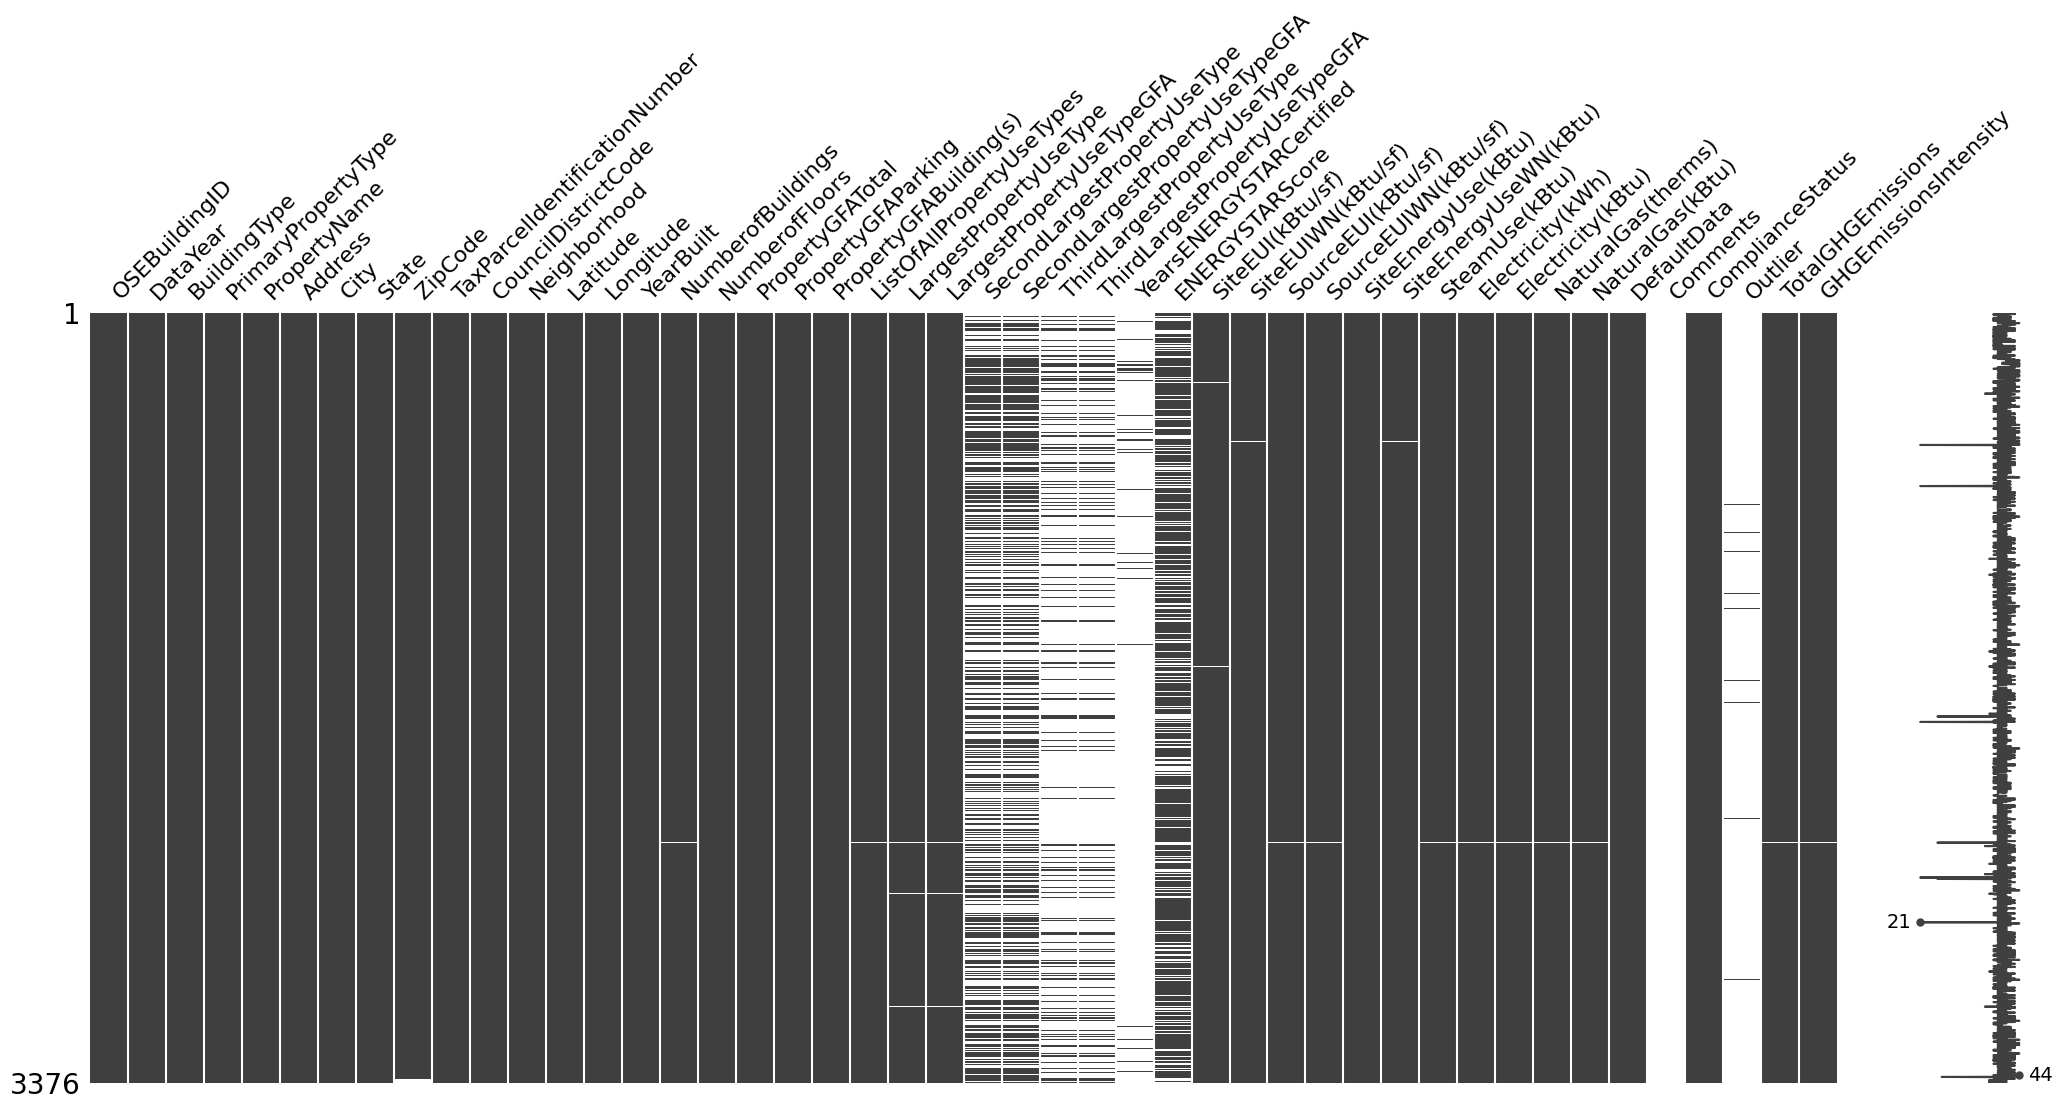

In [14]:
msno.matrix(df)

<Axes: >

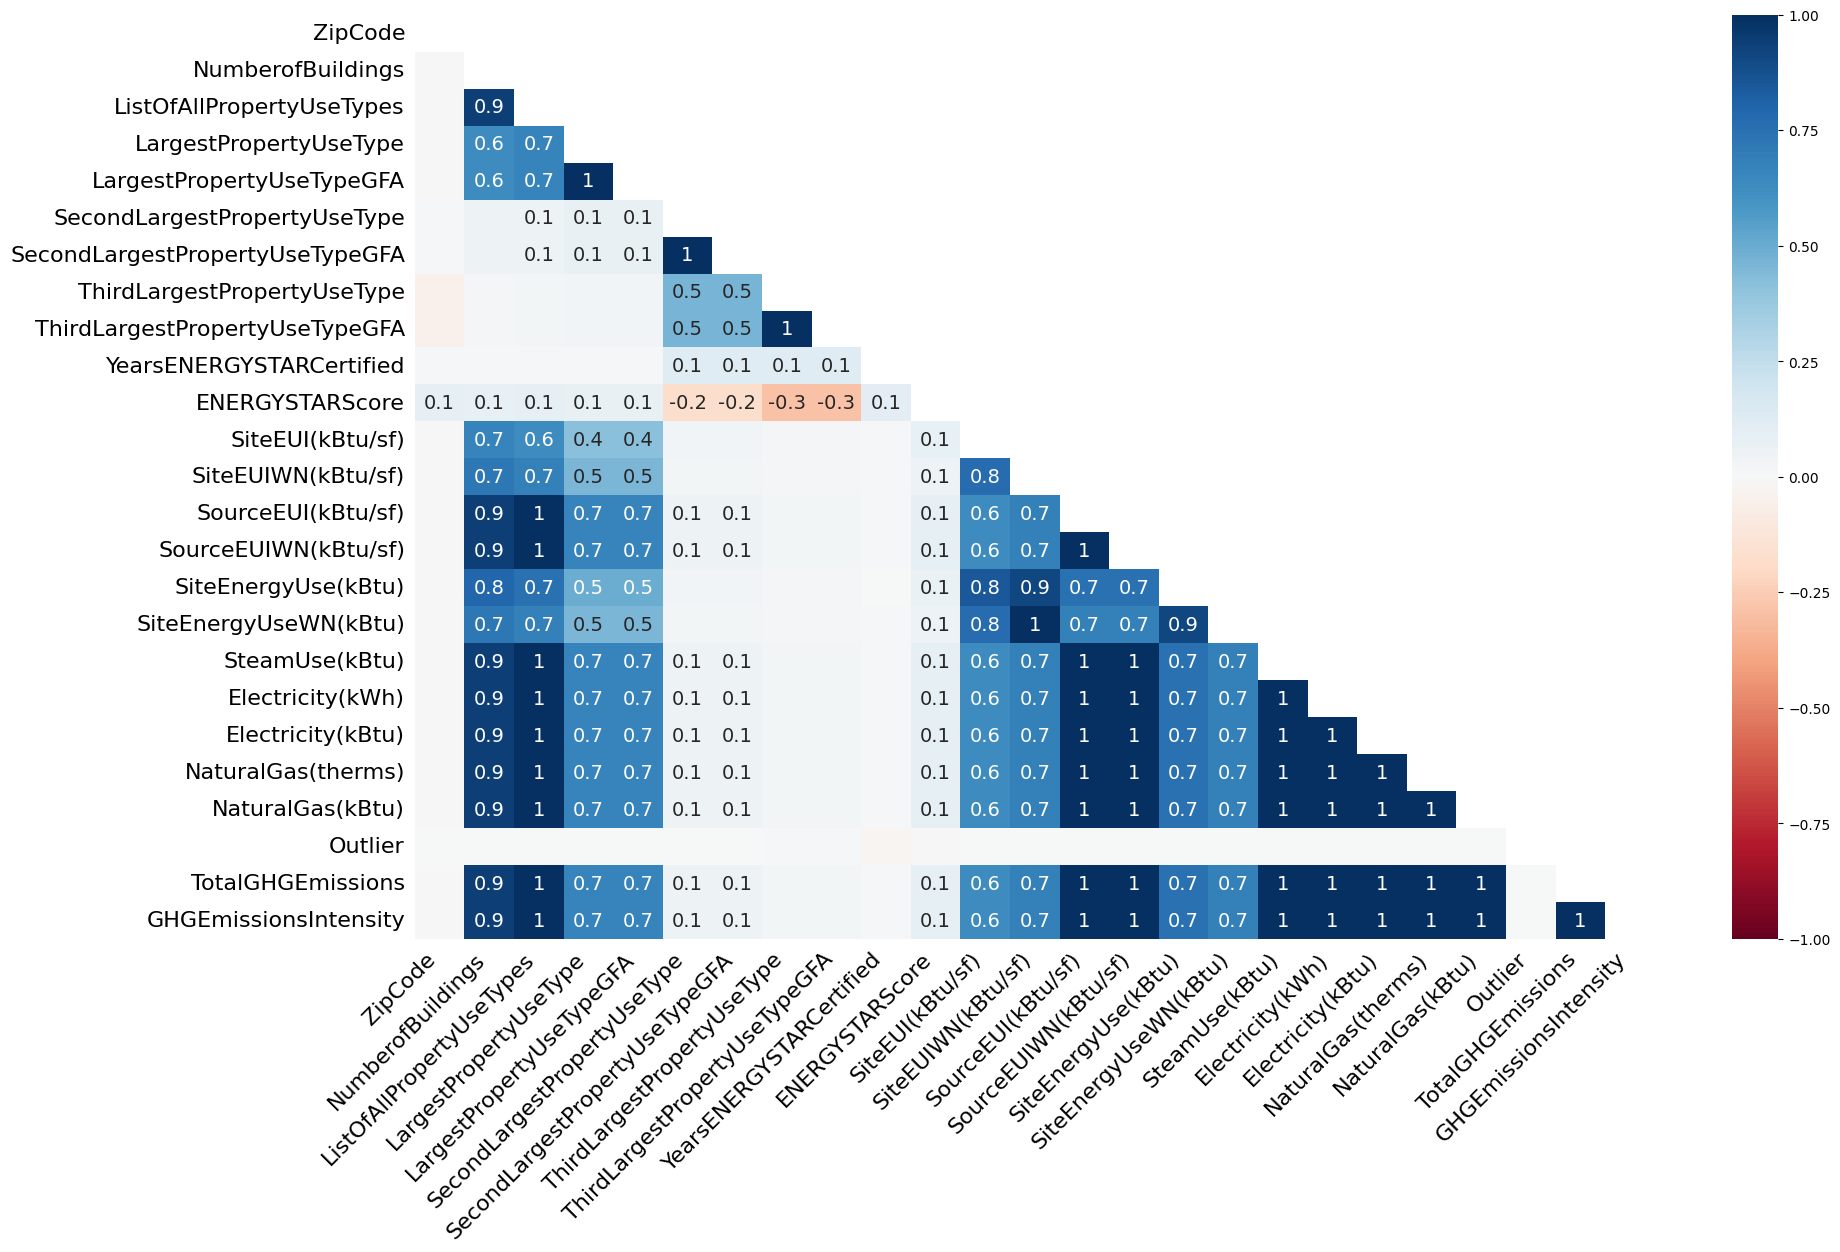

In [15]:
msno.heatmap(df)

<Axes: >

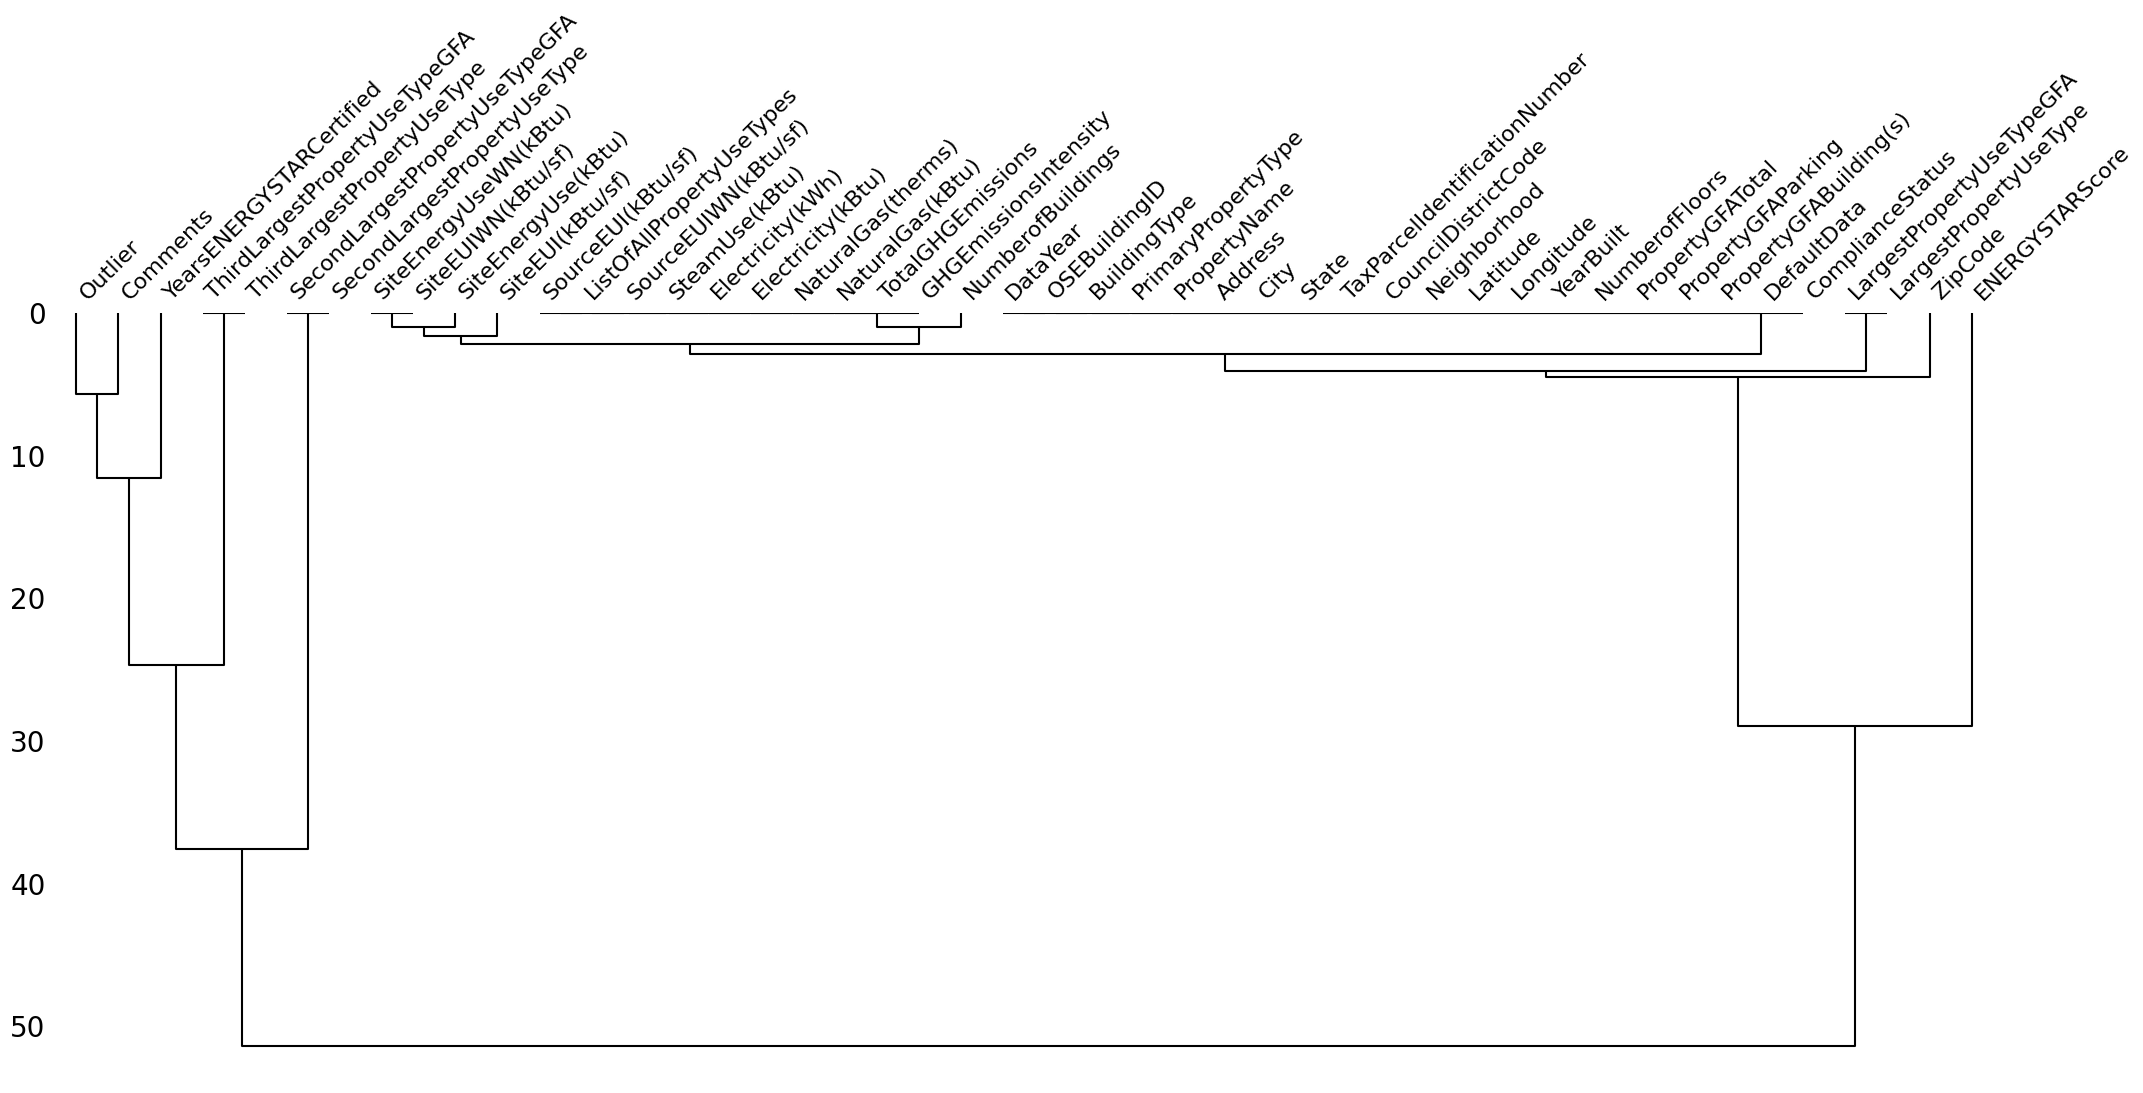

In [16]:
msno.dendrogram(df)

#### Colonne Comments ❌

In [17]:
df.drop(columns="Comments",inplace=True)

#### Colonne Outliers ✅

In [18]:
df[df["Outlier"].notna()]["Outlier"].value_counts()
# la colonne outliers a beaucoup de valeur vide mais elle a toutefois son utilité. Je vais la garder pour le moment.

Outlier
Low outlier     23
High outlier     9
Name: count, dtype: int64

#### Colonne YearsENERGYSTARCertified ❌ (création année's + nb_certification + first_cert_year) ✅

In [19]:
df[df["YearsENERGYSTARCertified"].notna()].sample()
# la colonne très intéressante, il faut :
# - Séparer les années tous les 4 caractères 
# - Créer les dummies par année

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
227,351,2016,NonResidential,Large Office,1111 Third Avenue,1111 3rd Ave Suite 310,Seattle,WA,"98,101.00",0942000050,7,DOWNTOWN,47.61,-122.34,1980,1.00,34,776762,162604,614158,"Office, Parking",Office,"606,050.00",Parking,"154,947.00",NaN,NaN,201620092008,81.00,53.70,53.80,168.30,168.40,"32,552,428.00","32,577,050.00",0.00,"9,512,705.00","32,457,349.00",950.76,"95,076.00",False,Compliant,NaN,231.32,0.30


In [20]:
def split_years(x):
    if pd.isna(x):
        return []
    x = str(x)
    return [x[i:i+4] for i in range(0, len(x), 4)]

df["Years_list"] = df["YearsENERGYSTARCertified"].apply(split_years)

In [21]:
df[df["YearsENERGYSTARCertified"].notna()][["YearsENERGYSTARCertified", "Years_list"]]

,YearsENERGYSTARCertified,Years_list
37,2016,[2016]
44,2016,[2016]
53,2014,[2014]
116,2016,[2016]
137,2016,[2016]
...,...,...
3281,20172016,"[2017, 2016]"
3293,2017,[2017]
3304,20172016,"[2017, 2016]"
3317,2017,[2017]


In [22]:
# Créer les dummies (One-hot encoding multi-label)
#mlb = MultiLabelBinarizer()

#years_dummies = pd.DataFrame(
#    mlb.fit_transform(df["Years_list"]), # type: ignore
#    columns=mlb.classes_,
#    index=df.index
#) # type: ignore
#years_dummies = years_dummies.astype(int)

In [23]:
#df = pd.concat([df, years_dummies], axis=1)

In [24]:
df["nb_certifications"] = df["Years_list"].apply(len)
df["first_cert_year"] = df["Years_list"].apply(lambda x: min(x) if x else np.nan)
df.drop(columns=["Years_list","YearsENERGYSTARCertified"],inplace=True)

In [25]:
df.head(2)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,nb_certifications,first_cert_year
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,"98,101.00",0659000030,7,DOWNTOWN,47.61,-122.34,1927,1.00,12,88434,0,88434,Hotel,Hotel,"88,434.00",NaN,NaN,NaN,NaN,60.00,81.70,84.30,182.50,189.00,"7,226,362.50","7,456,910.00","2,003,882.00","1,156,514.25","3,946,027.00","12,764.53","1,276,453.00",False,Compliant,NaN,249.98,2.83,0,NaN
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,"98,101.00",0659000220,7,DOWNTOWN,47.61,-122.33,1996,1.00,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,"83,880.00",Parking,"15,064.00",Restaurant,"4,622.00",61.00,94.80,97.90,176.10,179.40,"8,387,933.00","8,664,479.00",0.00,"950,425.19","3,242,851.00","51,450.82","5,145,082.00",False,Compliant,NaN,295.86,2.86,0,NaN


#### Colonne "Second" et "Third" ✅

In [26]:
df["nb_property_uses"] = (
    df["LargestPropertyUseType"].notna().astype(int) +
    df["SecondLargestPropertyUseType"].notna().astype(int) +
    df["ThirdLargestPropertyUseType"].notna().astype(int)
)

In [27]:
df["primary_use_ratio"] = (
    df["LargestPropertyUseTypeGFA"] / df["PropertyGFATotal"]
)

In [28]:
df["nb_property_uses"].value_counts()

nb_property_uses
1    1677
2    1083
3     596
0      20
Name: count, dtype: int64

/tmp/ipykernel_5210/223598007.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y="nb_property_uses", x="TotalGHGEmissions", data=data, orient="h", palette='Set2')


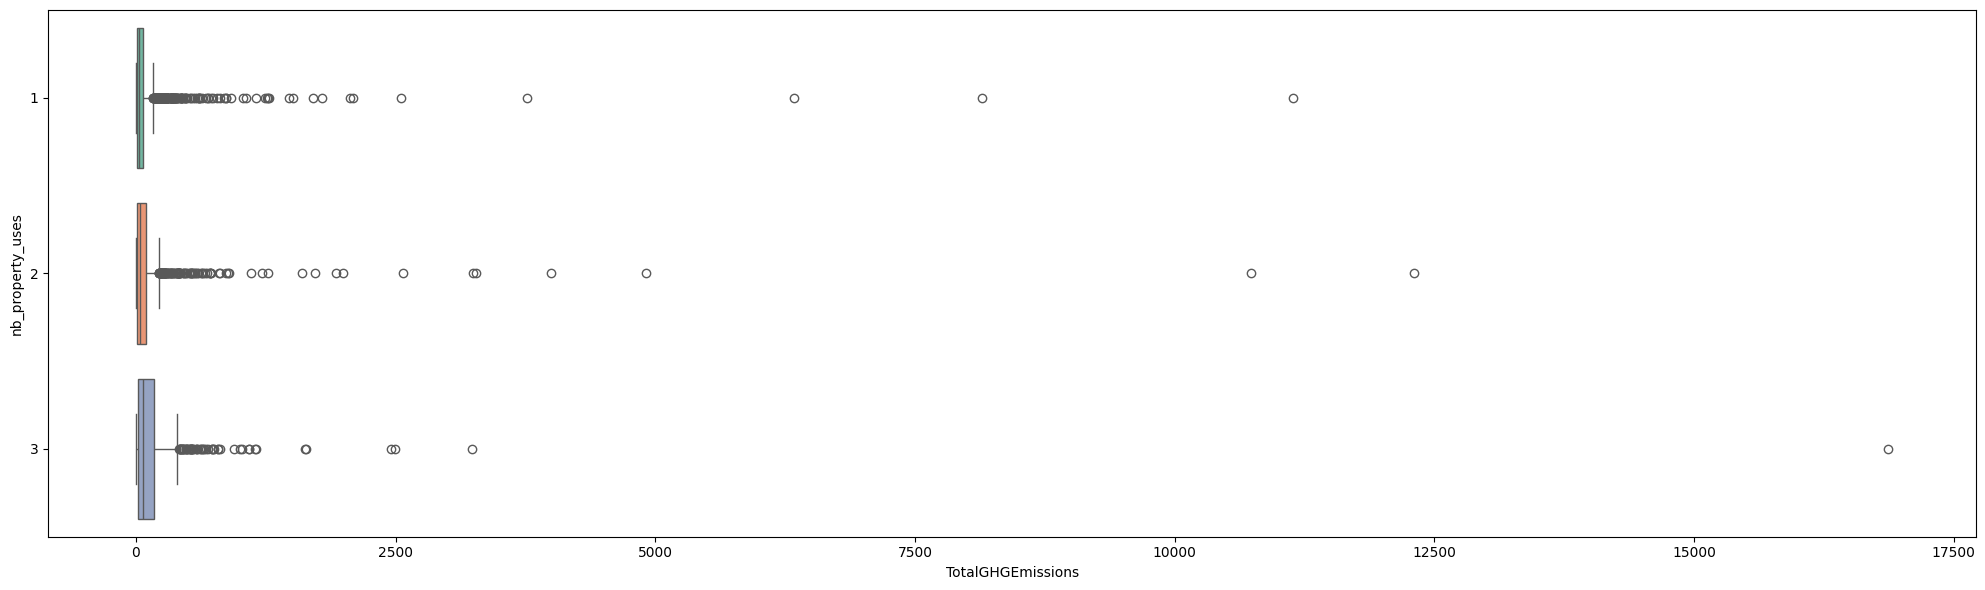

In [29]:
plt.figure(figsize=(20, 6))
data = df[df["nb_property_uses"] > 0]
sns.boxplot(y="nb_property_uses", x="TotalGHGEmissions", data=data, orient="h", palette='Set2')
plt.tight_layout()
plt.show()

In [30]:
df.groupby("nb_property_uses")["TotalGHGEmissions"].mean()

nb_property_uses
0    65.84
1    94.06
2   124.97
3   183.40
Name: TotalGHGEmissions, dtype: float64

In [31]:
df.groupby("nb_property_uses")["TotalGHGEmissions"].median()

nb_property_uses
0   18.95
1   26.41
2   34.00
3   63.25
Name: TotalGHGEmissions, dtype: float64

#### Colonne ListOfAllPropertyUseTypes ✅ (création de nb_property_uses et is_mixed_use)

In [32]:
df["nb_property_uses"] = (
    df["ListOfAllPropertyUseTypes"]
    .fillna("")  # évite les erreurs sur NaN
    .apply(lambda x: len([u.strip() for u in x.split(",") if u.strip() != ""]))
)

In [33]:
df[["ListOfAllPropertyUseTypes", "nb_property_uses"]].head(10)

,ListOfAllPropertyUseTypes,nb_property_uses
0,Hotel,1
1,"Hotel, Parking, Restaurant",3
2,Hotel,1
3,Hotel,1
4,"Hotel, Parking, Swimming Pool",3
5,Police Station,1
6,Hotel,1
7,Other - Entertainment/Public Assembly,1
8,Hotel,1
9,Multifamily Housing,1


In [34]:
df["is_mixed_use"] = (df["nb_property_uses"] > 1).astype(int)

### Outliers

In [35]:
outliers, ratio = of.detect_outliers_iqr(df.select_dtypes(include="number"))

ratio.sort_values(ascending=False)

OSEBuildingID                     26.60
PropertyGFAParking                14.93
Electricity(kWh)                  11.58
Electricity(kBtu)                 11.58
SiteEnergyUse(kBtu)               11.34
SiteEnergyUseWN(kBtu)             11.29
PropertyGFATotal                  10.96
TotalGHGEmissions                 10.87
LargestPropertyUseTypeGFA         10.49
PropertyGFABuilding(s)            10.22
NaturalGas(therms)                 9.95
NaturalGas(kBtu)                   9.95
SourceEUI(kBtu/sf)                 8.95
SourceEUIWN(kBtu/sf)               8.74
SiteEUI(kBtu/sf)                   7.82
GHGEmissionsIntensity              7.79
SiteEUIWN(kBtu/sf)                 7.43
NumberofFloors                     7.11
nb_property_uses                   6.78
SecondLargestPropertyUseTypeGFA    6.10
NumberofBuildings                  5.72
SteamUse(kBtu)                     3.85
nb_certifications                  3.52
ZipCode                            3.38
primary_use_ratio                  2.75


### Supprimer les doublons 👥 

In [36]:
df.duplicated().sum()

np.int64(0)

### Suppression des lignes avec "DefaultData" = True et ComplianceStatus = "Compliant"

In [37]:
df["DefaultData"].value_counts(normalize=True)

DefaultData
False   0.97
True    0.03
Name: proportion, dtype: float64

In [38]:
df["ComplianceStatus"].value_counts(normalize=True)

ComplianceStatus
Compliant                      0.95
Error - Correct Default Data   0.03
Non-Compliant                  0.01
Missing Data                   0.00
Name: proportion, dtype: float64

In [39]:
df = df[df["DefaultData"] == False].copy()
df = df[df["ComplianceStatus"] == "Compliant"].copy()
df.drop(columns=["DefaultData","ComplianceStatus"])
df.shape, building_consumption.shape

((3211, 49), (3376, 46))

### Suppression des lignes avce des building hors "bâtiments non destinés à l’habitation"

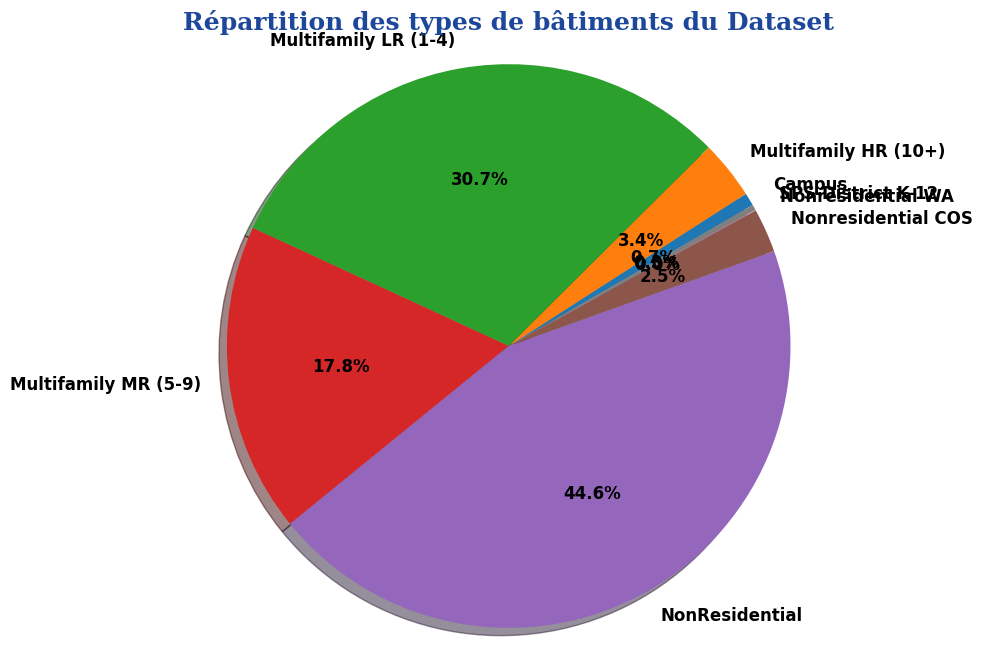

In [40]:
building_type = df.groupby(by='BuildingType')['OSEBuildingID'].nunique()

font_title = {'family': 'serif',
              'color':  '#1d479b',
              'weight': 'bold',
              'size': 18,
             }

fig, ax = plt.subplots(figsize=(8,8))
ax.pie(building_type.values, labels=building_type.index, 
       autopct='%1.1f%%', shadow=True, startangle=30,
       textprops=dict(color="black",size=12, weight="bold"))
ax.axis('equal')
ax.set_title("Répartition des types de bâtiments du Dataset", fontdict=font_title)
plt.show()

In [41]:
df.loc[(df['BuildingType']=="NonResidential"),'PrimaryPropertyType'].value_counts()

PrimaryPropertyType
Small- and Mid-Sized Office    282
Other                          181
Warehouse                      178
Large Office                   164
Mixed Use Property             101
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             51
Supermarket / Grocery Store     40
K-12 School                     38
Medical Office                  38
Self-Storage Facility           28
Residence Hall                  21
Senior Care Community           20
University                      17
Refrigerated Warehouse          12
Restaurant                      11
Hospital                        10
Laboratory                      10
Low-Rise Multifamily             1
Name: count, dtype: int64

On constate qu'il y a certains doublons dans la colonne PrimaryPropertyType.

In [42]:
regex = re.compile(r'[\n\r\t]')
df['PrimaryPropertyType'] = (
    df['PrimaryPropertyType']
        .str.replace(r'[\n\r\t]', '', regex=True)
)
df.loc[(df['BuildingType']=="NonResidential"),'PrimaryPropertyType'].value_counts()

PrimaryPropertyType
Small- and Mid-Sized Office    282
Other                          181
Warehouse                      178
Large Office                   164
Mixed Use Property             101
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             51
Supermarket / Grocery Store     40
K-12 School                     38
Medical Office                  38
Self-Storage Facility           28
Residence Hall                  21
Senior Care Community           20
University                      17
Refrigerated Warehouse          12
Restaurant                      11
Hospital                        10
Laboratory                      10
Low-Rise Multifamily             1
Name: count, dtype: int64

In [43]:
val = [
    'NonResidential',
    'Nonresidential COS',
   "Campus",
    "Nonresidential WA",
    "'SPS-District K-12'"
]

df = df[df["BuildingType"].isin(val)]

### Suppresion des lignes avec des Outliers 

In [44]:
df = df[~df["Outlier"].isnull() == False]
df.drop('Outlier', axis=1, inplace=True)

### Suppression des colonnes avec toujours la même valeurs

In [45]:
df.loc[:, df.nunique() == 1]

,DataYear,City,State,DefaultData,ComplianceStatus
0,2016,Seattle,WA,False,Compliant
1,2016,Seattle,WA,False,Compliant
2,2016,Seattle,WA,False,Compliant
3,2016,Seattle,WA,False,Compliant
4,2016,Seattle,WA,False,Compliant
...,...,...,...,...,...
3370,2016,Seattle,WA,False,Compliant
3372,2016,Seattle,WA,False,Compliant
3373,2016,Seattle,WA,False,Compliant
3374,2016,Seattle,WA,False,Compliant


In [46]:
df = df.loc[:, df.nunique() > 1]

### Suppression des variables redondantes

In [47]:
redundant_features = ['NaturalGas(therms)','Electricity(kWh)']
df.drop(redundant_features, axis=1, inplace=True)

In [48]:
df.sample(5)

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,nb_certifications,first_cert_year,nb_property_uses,primary_use_ratio,is_mixed_use
697,19654,NonResidential,Laboratory,1100 Olive Lab,1100 Olive Way,"98,101.00",0660002030,7,DOWNTOWN,47.62,-122.33,1946,1.00,2,44588,22000,22588,Laboratory,Laboratory,"69,000.00",NaN,NaN,NaN,NaN,NaN,105.10,105.10,330.00,330.00,"7,251,589.00","7,251,589.00",0.00,"7,251,588.00",0.00,50.55,1.13,0,NaN,1,1.55,0
1818,23504,NonResidential,Distribution Center,3223,3223 6th Avenue South,"98,134.00",7674800055,2,GREATER DUWAMISH,47.57,-122.33,1952,1.00,1,41308,0,41308,Distribution Center,Distribution Center,"41,308.00",NaN,NaN,NaN,NaN,7.00,39.80,43.40,95.10,98.90,"1,642,471.50","1,792,023.38",0.00,"1,054,767.00","587,704.00",38.57,0.93,0,NaN,1,1.00,0
3032,27947,NonResidential,Worship Facility,ST MARKS CATHEDRAL,1245 10th Avenue East,"98,102.00",6762700860,3,EAST,47.63,-122.32,1929,1.00,1,37700,0,37700,Worship Facility,Worship Facility,"52,225.00",NaN,NaN,NaN,NaN,38.00,66.70,80.30,100.10,115.70,"3,481,727.50","4,195,549.50",0.00,"751,827.00","2,729,901.00",150.23,3.98,0,NaN,1,1.39,0
343,482,NonResidential,Large Office,Westlake Terry - West SEDO,320 Westlake Ave. N.,"98,109.00",1986200215,7,LAKE UNION,47.62,-122.34,2006,1.00,6,303103,109905,193198,"Bank Branch, Office, Parking",Office,"178,628.00",Parking,"99,368.00",Bank Branch,"6,015.00",97.00,40.70,40.90,123.70,123.90,"7,519,466.50","7,554,767.00",0.00,"7,147,457.00","372,009.00",69.59,0.23,6,2009,3,0.59,1
1465,21897,NonResidential,Warehouse,9243 10TH AVE S (ID21897),9243 10TH AVE S,"98,108.00",2433700075,1,GREATER DUWAMISH,47.52,-122.32,1978,1.00,1,22176,0,22176,Non-Refrigerated Warehouse,Non-Refrigerated Warehouse,"22,176.00",NaN,NaN,NaN,NaN,60.00,33.20,33.70,47.80,49.30,"736,428.62","746,905.62",0.00,"137,469.00","598,959.00",32.77,1.48,0,NaN,1,1.00,0


### Suppresion des colonnes WN

Les suffixes WN : "Weather Normalized" - Ce sont les mesures normalisées avec les conditions climatiques. Dans le cadre de notre analyse, la météo ne rentrera pas en compte.

In [49]:
def search_componant(df, suffix=None):
  componant = []
  for col in df.columns:
      if suffix in col: 
        componant.append(col)
  return componant

In [50]:
df.drop(search_componant(df,'WN'), axis=1, inplace=True)

## Analyse univariée

In [51]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
OSEBuildingID,"1,538.00","16,527.60","13,835.26",1.00,604.25,"21,182.50","24,619.00","50,226.00"
ZipCode,"1,525.00","98,116.66",18.56,"98,006.00","98,104.00","98,109.00","98,125.00","98,199.00"
CouncilDistrictCode,"1,538.00",4.41,2.19,1.00,2.00,4.00,7.00,7.00
Latitude,"1,538.00",47.62,0.05,47.51,47.59,47.61,47.65,47.73
Longitude,"1,538.00",-122.33,0.02,-122.41,-122.34,-122.33,-122.32,-122.26
YearBuilt,"1,538.00","1,961.54",32.87,"1,900.00","1,930.00","1,965.00","1,988.00","2,015.00"
NumberofBuildings,"1,538.00",1.18,3.05,0.00,1.00,1.00,1.00,111.00
NumberofFloors,"1,538.00",4.29,6.80,0.00,1.00,2.00,4.00,99.00
PropertyGFATotal,"1,538.00","121,122.57","307,114.22","11,285.00","28,811.00","48,013.00","106,030.75","9,320,156.00"
PropertyGFAParking,"1,538.00","13,932.34","43,849.52",0.00,0.00,0.00,0.00,"512,608.00"


### Colonnes numérique ALL

In [52]:
data = df.select_dtypes(include="number").copy()

In [53]:
cols_to_drop = [
    "OSEBuildingID", "ZipCode","CouncilDistrictCode",
    "Latitude","Longitude","YearBuilt", 'is_mixed_use','nb_certifications',"nb_property_uses","NumberofBuildings","NumberofFloors"
]

data = data.drop(cols_to_drop,axis=1)

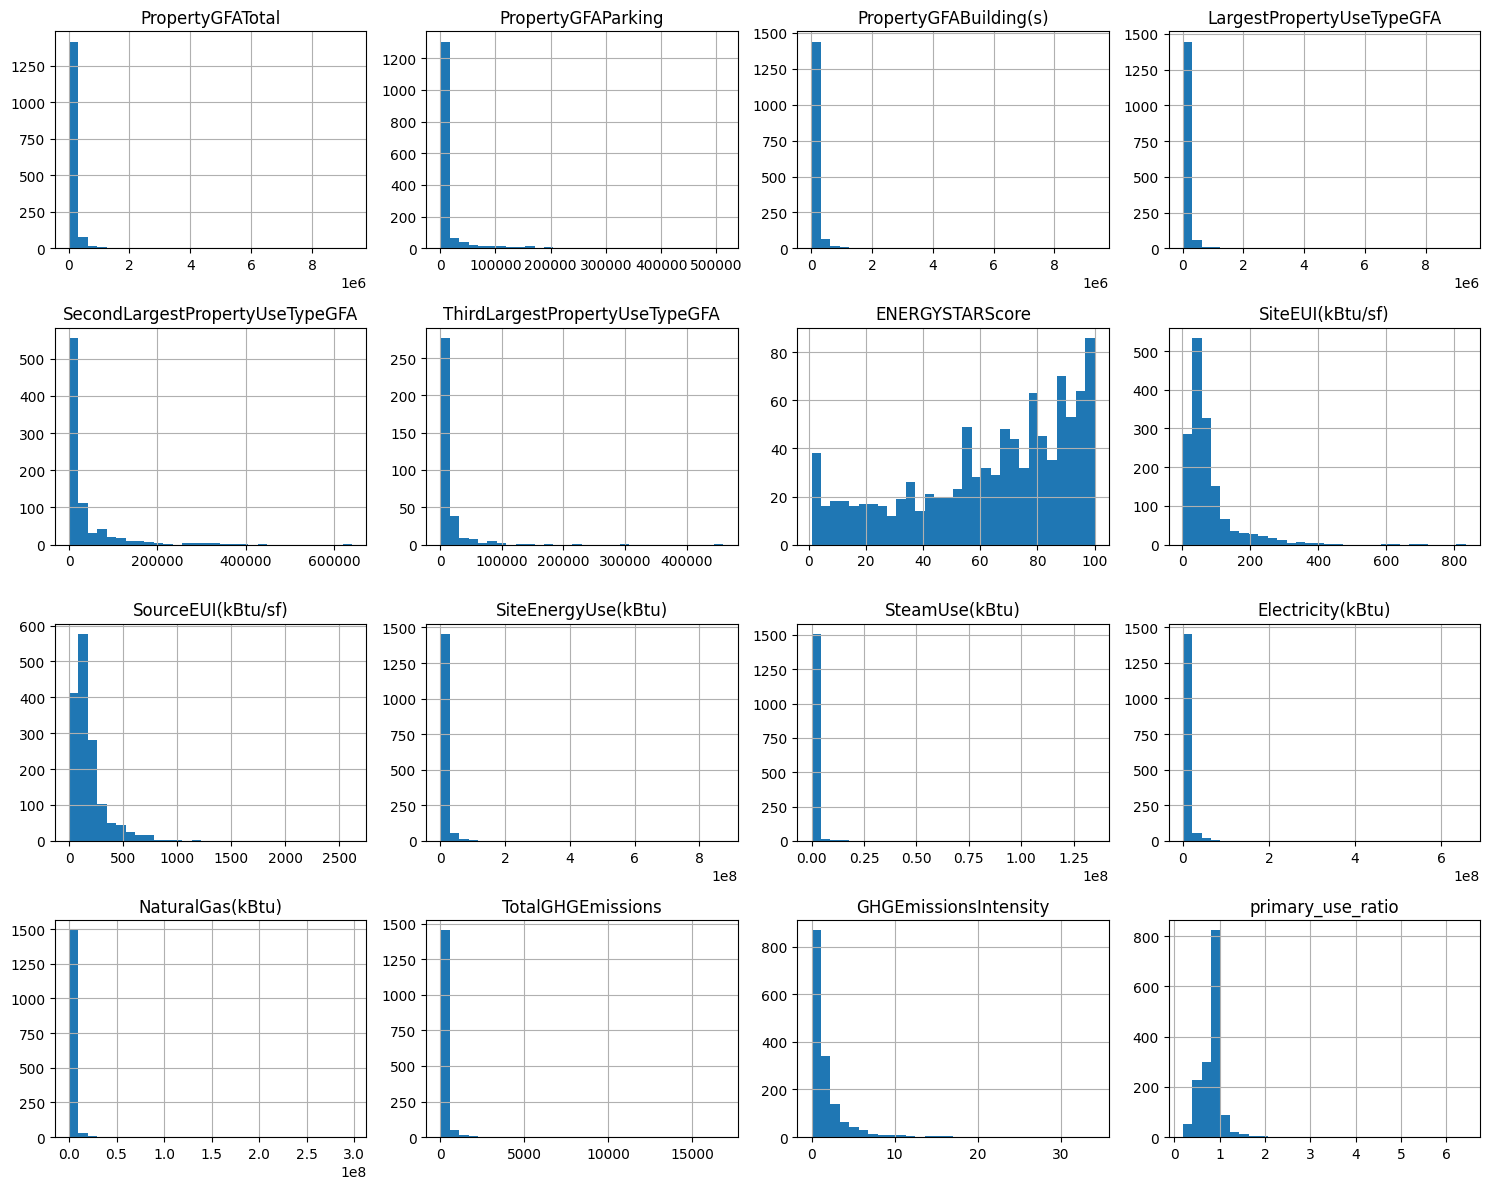

In [54]:
data.hist(bins=30, figsize=(15,12))
plt.tight_layout()
plt.show()

In [55]:
data.skew().sort_values(ascending=False) # asymértie des données sur la droite (sauf ENERGYSTARScore) ==> normaliser les données pour avoir une meilleure distribution

LargestPropertyUseTypeGFA         22.74
NaturalGas(kBtu)                  21.30
PropertyGFABuilding(s)            21.28
Electricity(kBtu)                 20.18
PropertyGFATotal                  18.79
SteamUse(kBtu)                    18.39
SiteEnergyUse(kBtu)               17.42
TotalGHGEmissions                 13.68
ThirdLargestPropertyUseTypeGFA     7.57
primary_use_ratio                  5.85
PropertyGFAParking                 5.01
SourceEUI(kBtu/sf)                 4.94
GHGEmissionsIntensity              4.55
SecondLargestPropertyUseTypeGFA    3.76
SiteEUI(kBtu/sf)                   3.68
ENERGYSTARScore                   -0.66
dtype: float64

/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


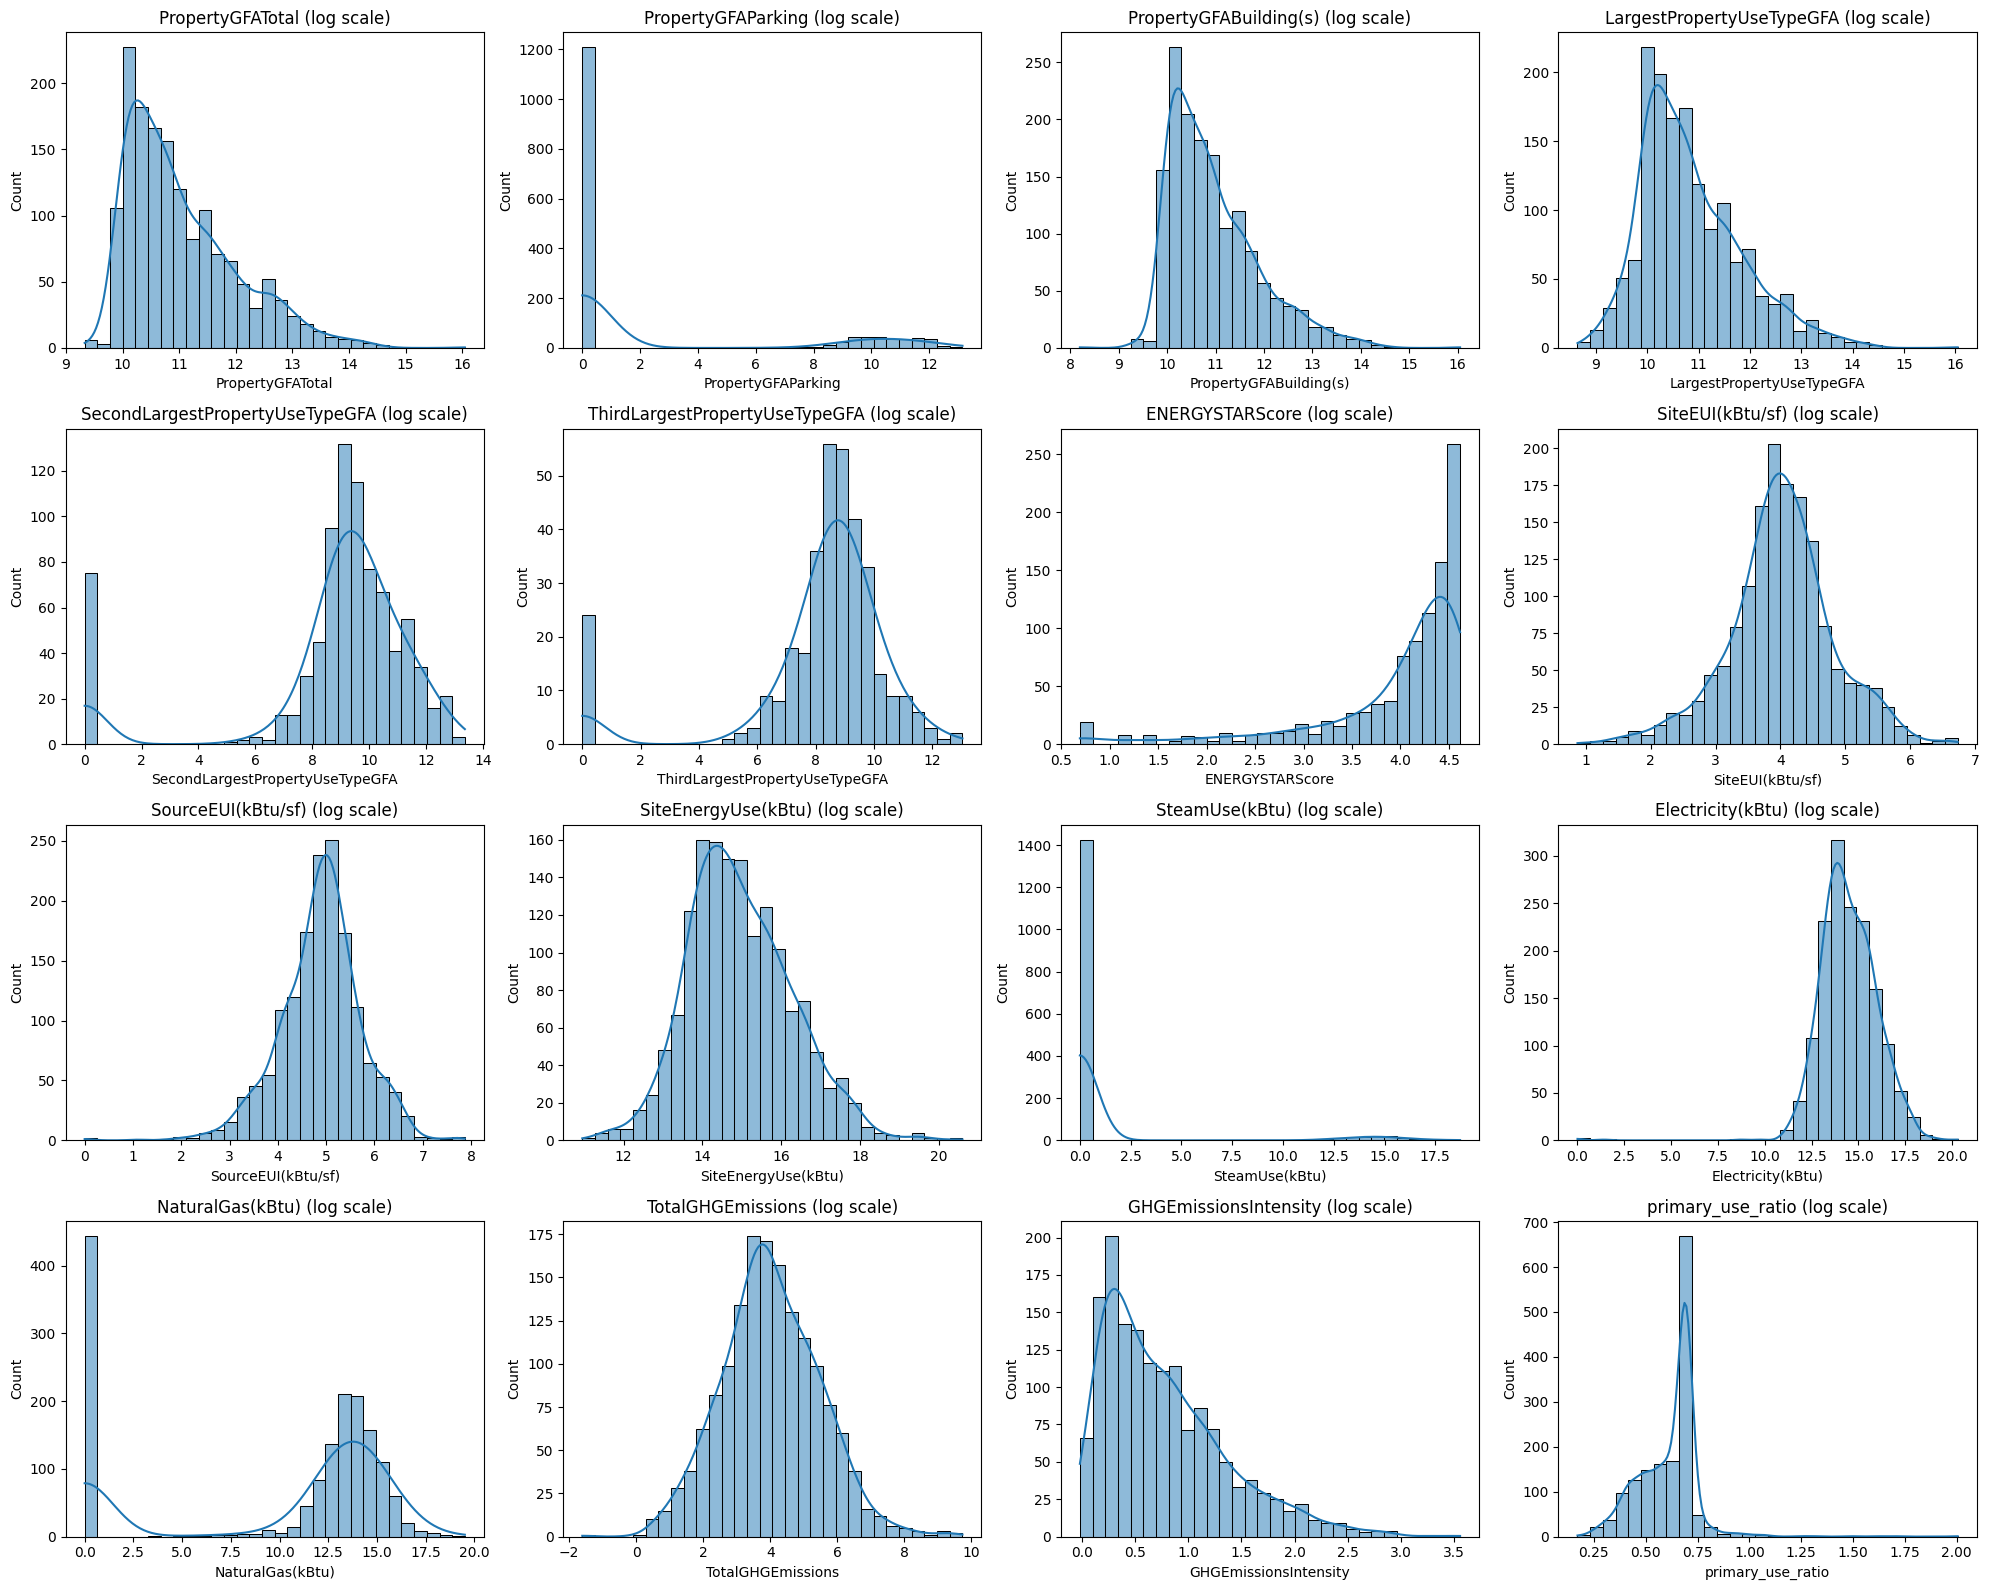

In [56]:
cols = data.columns
n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))

axes = axes.flatten()  # pour itérer facilement

for i, col in enumerate(cols):
    sns.histplot(np.log1p(data[col]), bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} (log scale)")

# Supprimer les axes vides si nombre impair
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Colonnes numériques sélectionnées

In [57]:
df.select_dtypes(include="number").sample(5)

,OSEBuildingID,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,nb_certifications,nb_property_uses,primary_use_ratio,is_mixed_use
742,19766,"98,116.00",1,47.57,-122.41,1926,1.00,2,22128,0,22128,"22,128.00",NaN,NaN,94.00,27.50,43.30,"608,359.69",0.00,"153,306.00","455,054.00",25.24,1.14,0,1,1.00,0
2157,24624,"98,103.00",4,47.65,-122.34,1940,1.00,2,41293,15243,26050,"26,393.00","15,000.00",NaN,NaN,68.60,169.60,"2,839,882.25",0.00,"1,932,090.00","907,792.00",61.68,1.49,0,2,0.64,1
1025,20532,"98,134.00",3,47.58,-122.30,1977,0.00,1,36070,0,36070,"66,597.00",NaN,NaN,NaN,21.60,68.00,"1,441,665.38",0.00,"1,441,665.00",0.00,10.05,0.28,0,1,1.85,0
1950,23930,"98,134.00",2,47.56,-122.34,1968,1.00,1,160000,0,160000,"160,000.00",NaN,NaN,94.00,7.20,22.70,"1,157,976.50",0.00,"1,157,977.00",0.00,8.07,0.05,0,1,1.00,0
536,725,"98,134.00",2,47.57,-122.33,1961,1.00,1,73335,0,73335,"73,335.00",0.00,NaN,NaN,70.90,148.70,"5,197,118.00",0.00,"2,606,839.00","2,590,279.00",155.74,2.12,0,2,1.00,1


In [58]:
col_sel = [
    "CouncilDistrictCode",
    "YearBuilt",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFATotal",
    "SiteEnergyUse(kBtu)",
    "SiteEUI(kBtu/sf)",
    "SourceEUI(kBtu/sf)",
    "TotalGHGEmissions",
    "GHGEmissionsIntensity",
    "ENERGYSTARScore",
    "SteamUse(kBtu)",
    "Electricity(kBtu)",
    "nb_certifications",	
    "nb_property_uses",	
    "primary_use_ratio",	
    "is_mixed_use"   
]

In [59]:
regex = re.compile(r'[\n\r\t]')
df['PrimaryPropertyType'] = (
    df['PrimaryPropertyType']
        .str.replace(r'[\n\r\t]', '', regex=True)
)
df.loc[(df['BuildingType']=="NonResidential"),'PrimaryPropertyType'].value_counts()

PrimaryPropertyType
Small- and Mid-Sized Office    282
Other                          181
Warehouse                      178
Large Office                   164
Mixed Use Property             101
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             51
Supermarket / Grocery Store     40
K-12 School                     38
Medical Office                  38
Self-Storage Facility           28
Residence Hall                  21
Senior Care Community           20
University                      17
Refrigerated Warehouse          12
Restaurant                      11
Hospital                        10
Laboratory                      10
Low-Rise Multifamily             1
Name: count, dtype: int64

In [60]:
data = df[col_sel].copy()

In [61]:
data.skew() # Toutes valeurs des colonnes ont un skewness > 0. Ce qui signifie est asymétrique à gauche. 
# Pour avoir une meilleure visualisation, je vais log les données.

CouncilDistrictCode     -0.02
YearBuilt               -0.28
NumberofBuildings       31.26
NumberofFloors           5.82
PropertyGFATotal        18.79
SiteEnergyUse(kBtu)     17.42
SiteEUI(kBtu/sf)         3.68
SourceEUI(kBtu/sf)       4.94
TotalGHGEmissions       13.68
GHGEmissionsIntensity    4.55
ENERGYSTARScore         -0.66
SteamUse(kBtu)          18.39
Electricity(kBtu)       20.18
nb_certifications        7.03
nb_property_uses         2.19
primary_use_ratio        5.85
is_mixed_use            -0.19
dtype: float64

/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


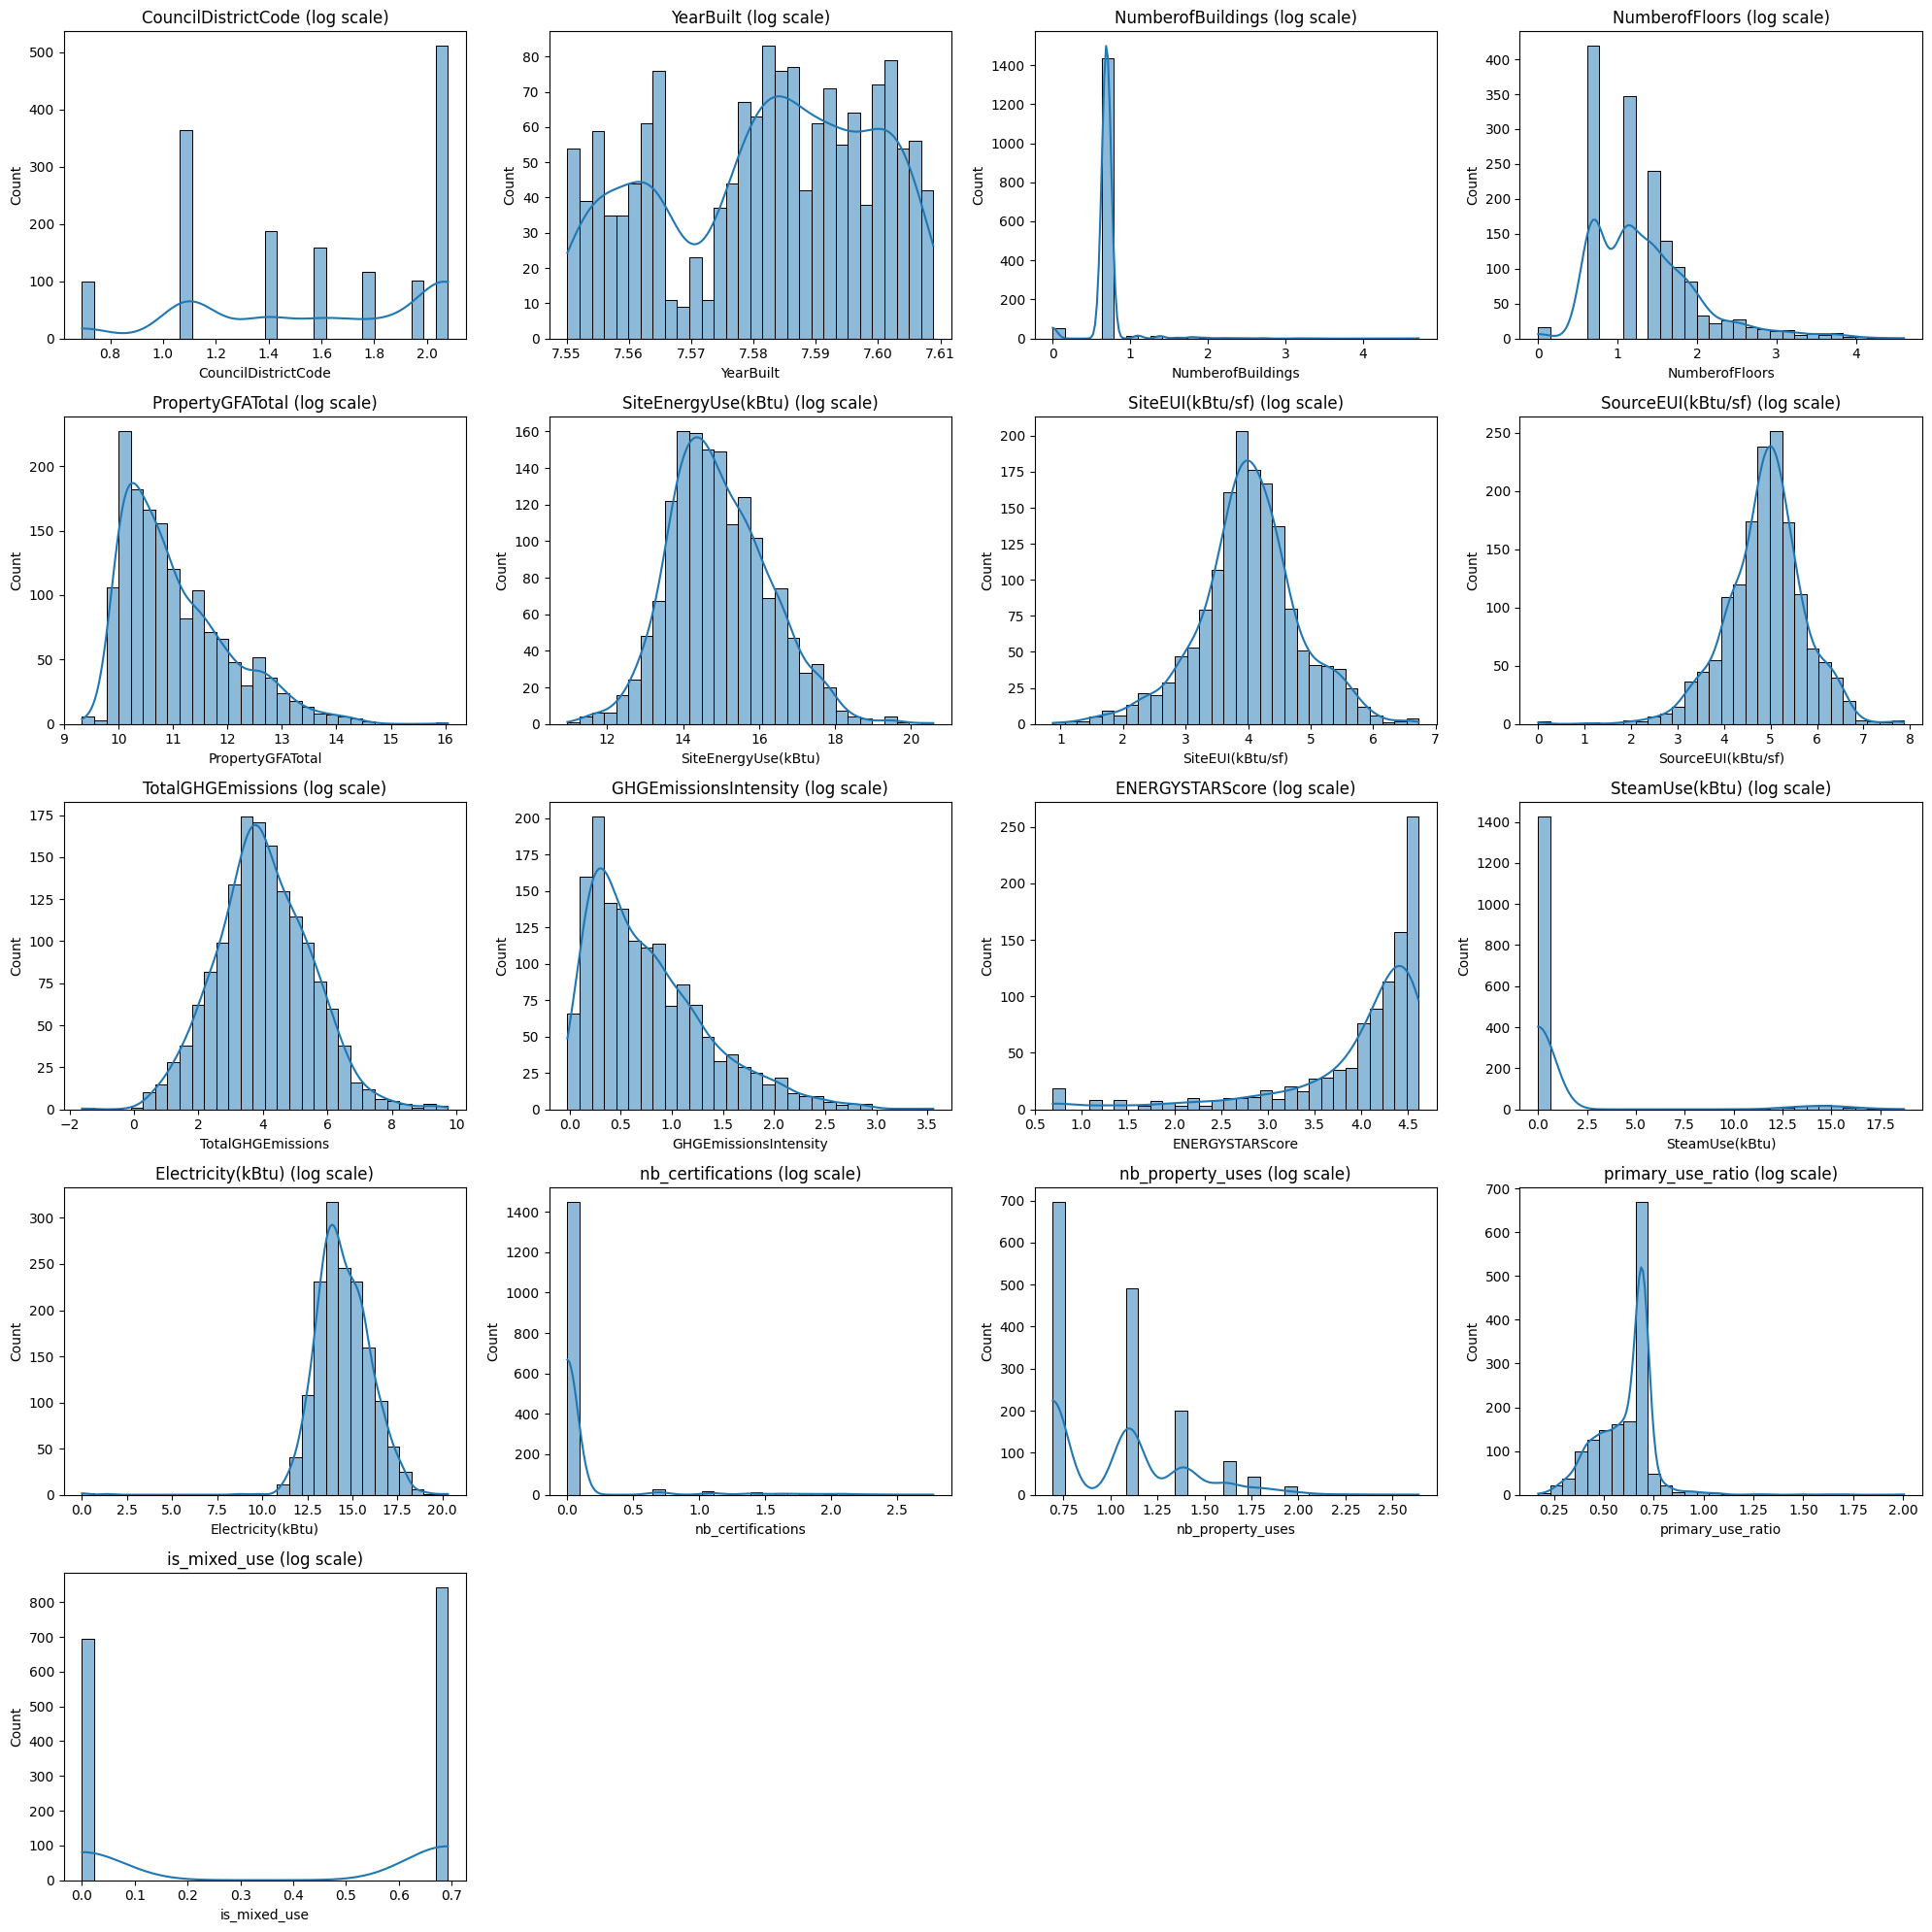

In [62]:
cols = data.columns
n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))

axes = axes.flatten()  # pour itérer facilement

for i, col in enumerate(cols):
    sns.histplot(np.log1p(data[col]), bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} (log scale)")

# Supprimer les axes vides si nombre impair
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


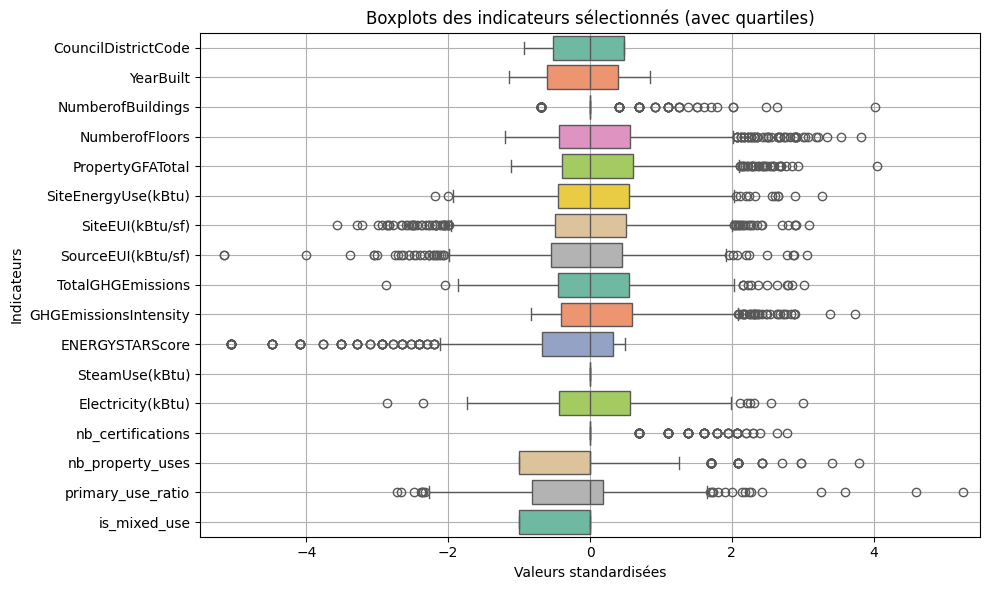

In [63]:
data_log = np.log1p(data)

data_scaled = pd.DataFrame(
    RobustScaler().fit_transform(data_log),
    columns=data.columns
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data_scaled,
    orient="h",
    palette="Set2",
    saturation=0.8
)

plt.title("Boxplots des indicateurs sélectionnés (avec quartiles)")
plt.ylabel("Indicateurs")
plt.xlabel("Valeurs standardisées")
plt.xlim(-5.5, 5.5)
plt.grid(True)
plt.tight_layout()
plt.show()


Les consommations et émissions sont fortement concentrées sur un petit nombre de bâtiments.

In [64]:
outliers, ratio = of.detect_outliers_iqr(data)

ratio.sort_values(ascending=False)

PropertyGFATotal        12.48
SiteEnergyUse(kBtu)     11.38
Electricity(kBtu)       11.25
TotalGHGEmissions       10.92
nb_property_uses         9.82
SiteEUI(kBtu/sf)         9.43
NumberofFloors           8.97
GHGEmissionsIntensity    8.71
SourceEUI(kBtu/sf)       7.93
SteamUse(kBtu)           7.35
NumberofBuildings        6.76
nb_certifications        5.92
primary_use_ratio        1.56
CouncilDistrictCode      0.00
YearBuilt                0.00
ENERGYSTARScore          0.00
is_mixed_use             0.00
dtype: float64

### Colonnes catégorielles ALL

In [65]:
cat_cols = [
       'PrimaryPropertyType', 'PropertyName', 'Address',
       'TaxParcelIdentificationNumber', 'Neighborhood',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType',
       'first_cert_year',
       'is_mixed_use','nb_certifications',"nb_property_uses","NumberofBuildings","NumberofFloors"
]

In [66]:
# Nombre de modalités
for col in cat_cols:
    print(col, ":", df[col].nunique())

PrimaryPropertyType : 21
PropertyName : 1534
Address : 1517
TaxParcelIdentificationNumber : 1458
Neighborhood : 19
ListOfAllPropertyUseTypes : 369
LargestPropertyUseType : 55
SecondLargestPropertyUseType : 47
ThirdLargestPropertyUseType : 39
first_cert_year : 16
is_mixed_use : 2
nb_certifications : 13
nb_property_uses : 11
NumberofBuildings : 16
NumberofFloors : 45


In [67]:
# Distribution brute
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts(dropna=False).head(10))


 PrimaryPropertyType
PrimaryPropertyType
Small- and Mid-Sized Office    286
Other                          243
Warehouse                      185
Large Office                   169
Mixed Use Property             113
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             53
K-12 School                     42
Name: count, dtype: int64

 PropertyName
PropertyName
South Park                     2
Canal Building                 2
Bayview Building               2
Airport Way                    2
Mayflower park hotel           1
Paramount Hotel                1
5673-The Westin Seattle        1
HOTEL MAX                      1
WARWICK SEATTLE HOTEL (ID8)    1
West Precinct                  1
Name: count, dtype: int64

 Address
Address
2600 SW Barton St              4
2203 Airport Way S             4
309 South Cloverdale Street    4
500 5TH AVE                    2
3613 4th Ave S                 2
516 1st Ave W  

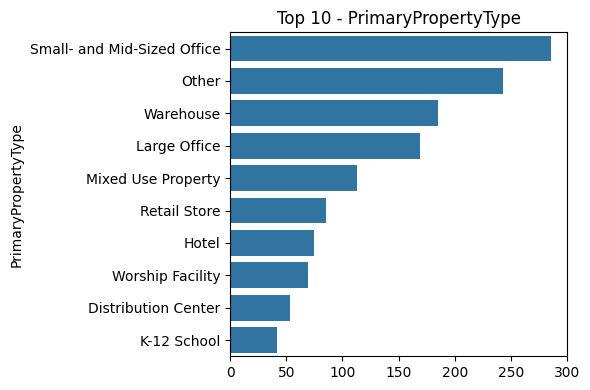

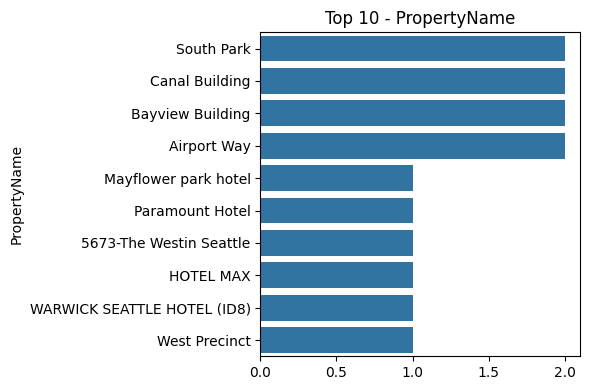

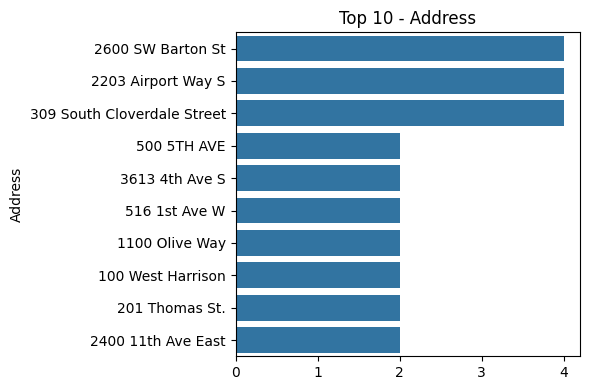

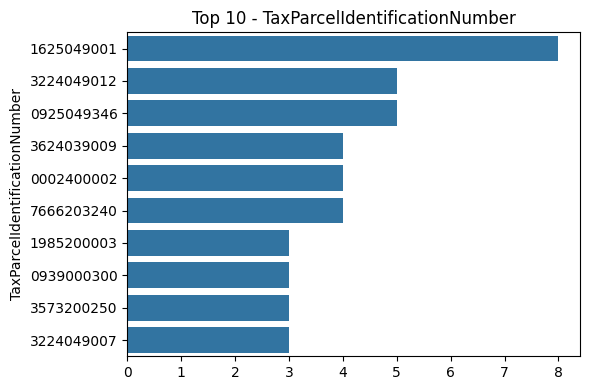

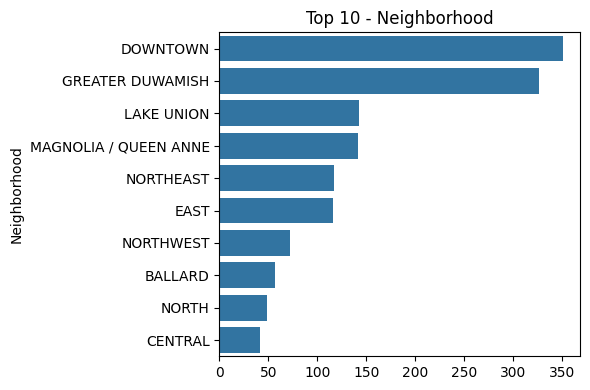

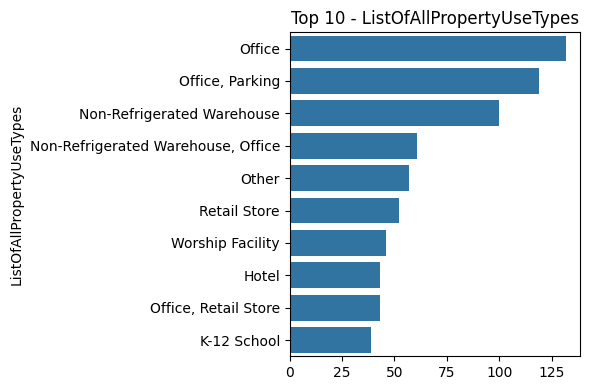

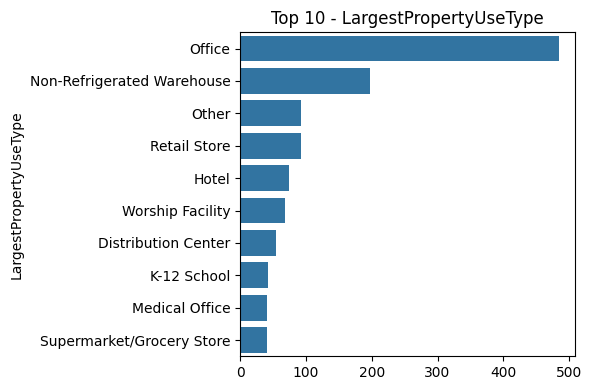

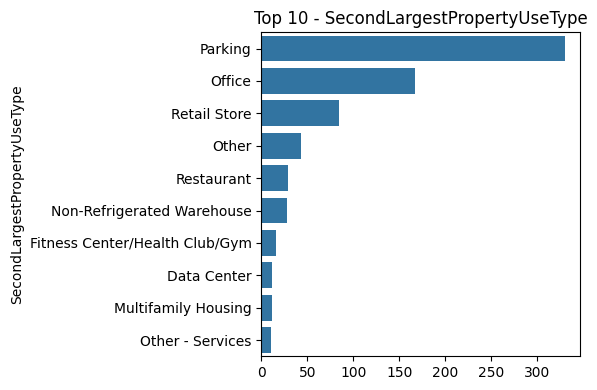

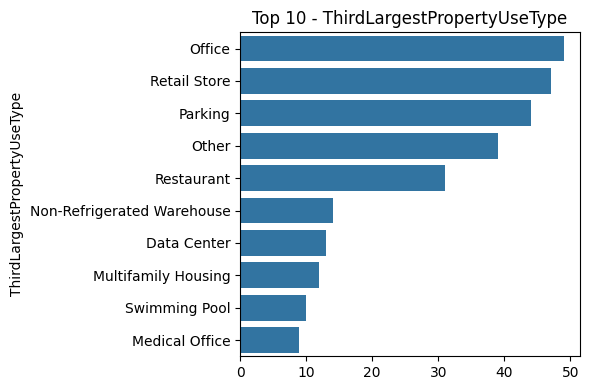

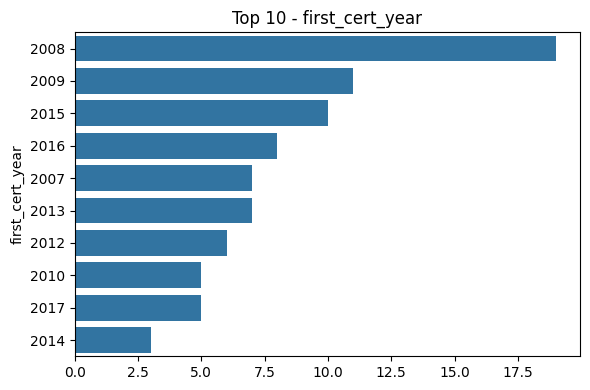

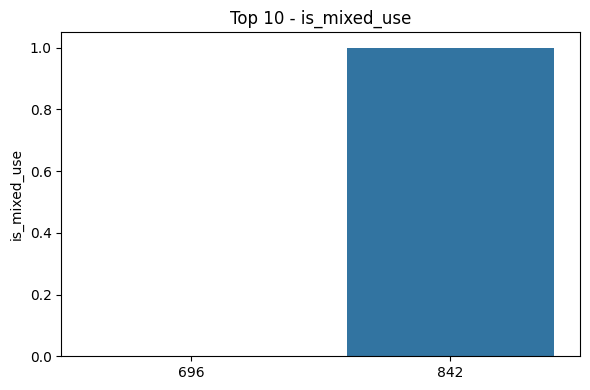

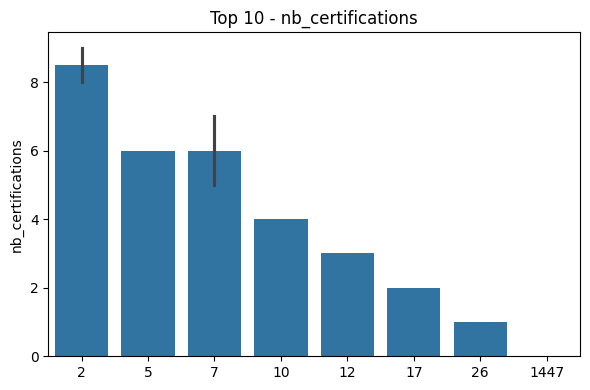

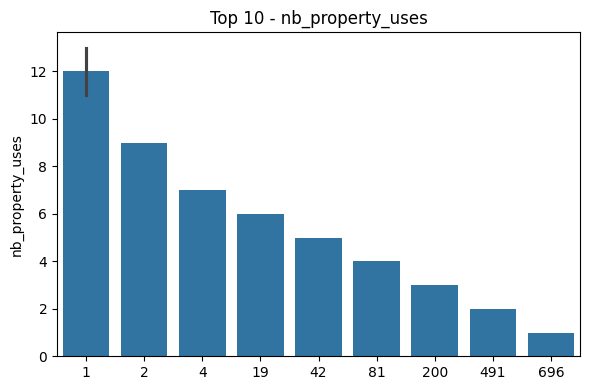

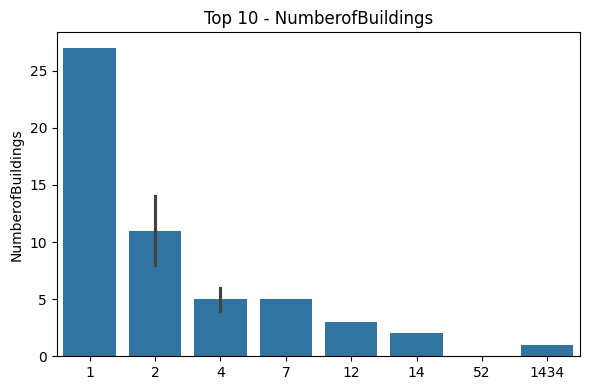

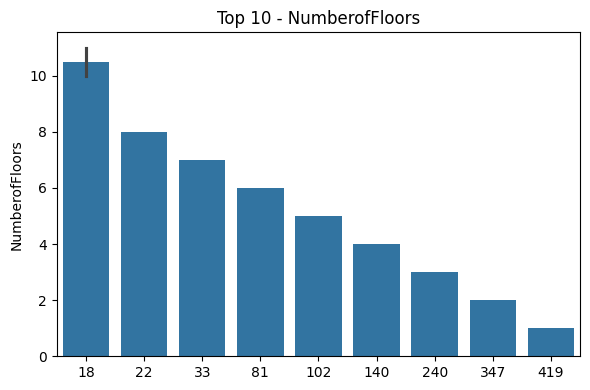

In [68]:
for col in cat_cols:
    
    plt.figure(figsize=(6,4))
    
    top_categories = df[col].value_counts().nlargest(10)
    
    sns.barplot(
        x=top_categories.values,
        y=top_categories.index
    )
    
    plt.title(f"Top 10 - {col}")
    plt.tight_layout()
    plt.show()

## Analyse bivariée

In [69]:
col_sel

['CouncilDistrictCode',
 'YearBuilt',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'SiteEnergyUse(kBtu)',
 'SiteEUI(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'TotalGHGEmissions',
 'GHGEmissionsIntensity',
 'ENERGYSTARScore',
 'SteamUse(kBtu)',
 'Electricity(kBtu)',
 'nb_certifications',
 'nb_property_uses',
 'primary_use_ratio',
 'is_mixed_use']

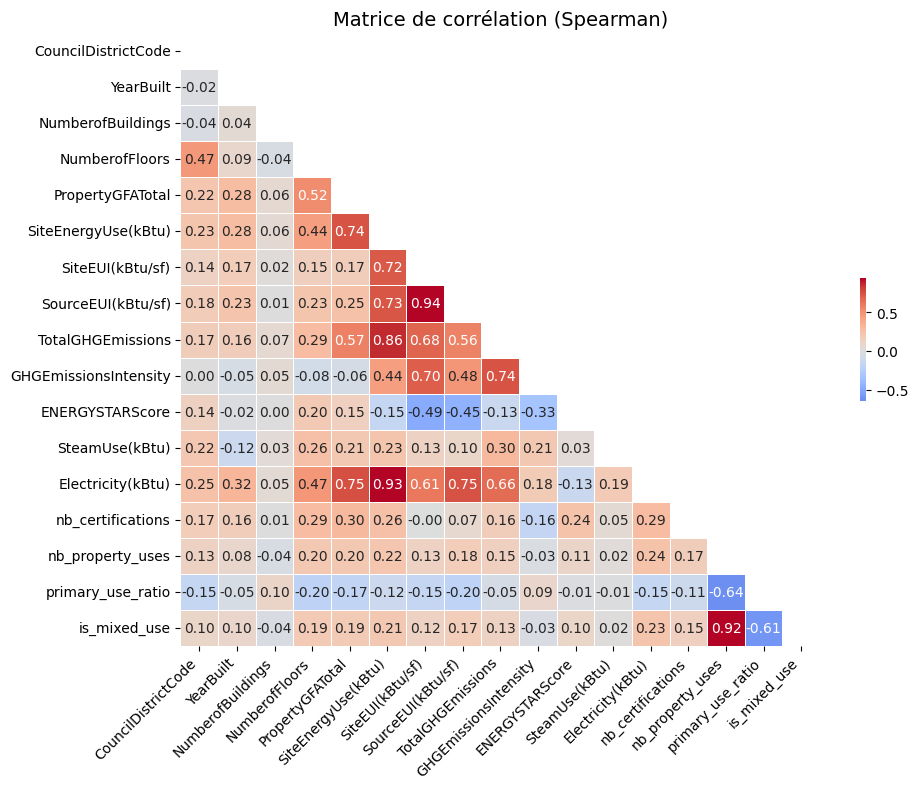

In [70]:
data = df[col_sel]

corr_matrix = data.corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.2}
)
plt.title("Matrice de corrélation (Spearman)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Problème de colinéarité

In [71]:
corr = df.select_dtypes(include="number").corr(method="spearman")

threshold = 0.7
corr_pairs = corr.unstack().sort_values()
strong_corr = (pd.DataFrame(corr_pairs[(abs(corr_pairs) > threshold)])
               .reset_index().rename(columns={0:'corr_coeff'}))
strong_corr = strong_corr[(strong_corr.index%2 == 0) & (strong_corr['level_0'] != strong_corr['level_1'])]
strong_corr.sort_values('corr_coeff', ascending=False)

,level_0,level_1,corr_coeff
38,PropertyGFATotal,PropertyGFABuilding(s),0.98
36,SourceEUI(kBtu/sf),SiteEUI(kBtu/sf),0.94
34,Electricity(kBtu),SiteEnergyUse(kBtu),0.93
32,nb_property_uses,is_mixed_use,0.92
30,LargestPropertyUseTypeGFA,PropertyGFATotal,0.92
28,LargestPropertyUseTypeGFA,PropertyGFABuilding(s),0.92
26,SiteEnergyUse(kBtu),TotalGHGEmissions,0.86
24,GHGEmissionsIntensity,NaturalGas(kBtu),0.76
22,Electricity(kBtu),PropertyGFATotal,0.75
20,SourceEUI(kBtu/sf),Electricity(kBtu),0.75


In [72]:
corr = df.select_dtypes(include="number").corr(method="spearman")

mask = np.triu(np.ones_like(corr, dtype=bool)) # matrice de 1 de la même taille que corr + garde uniquement la partie triangulaire supérieure
corr_tri = corr.mask(mask) # suppression de la diagonale et de la partie supérieur de la matrice

strong_corr = (pd.DataFrame(
    corr_tri.unstack()
    .dropna()
    .loc[lambda x: abs(x) > 0.7]
    .sort_values(ascending=False)
    .reset_index()
    )
)
strong_corr.columns = ["level_0", "level_1", "corr"]
strong_corr

,level_0,level_1,corr
0,PropertyGFATotal,PropertyGFABuilding(s),0.98
1,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),0.94
2,SiteEnergyUse(kBtu),Electricity(kBtu),0.93
3,nb_property_uses,is_mixed_use,0.92
4,PropertyGFATotal,LargestPropertyUseTypeGFA,0.92
5,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,0.92
6,SiteEnergyUse(kBtu),TotalGHGEmissions,0.86
7,NaturalGas(kBtu),GHGEmissionsIntensity,0.76
8,PropertyGFATotal,Electricity(kBtu),0.75
9,SourceEUI(kBtu/sf),Electricity(kBtu),0.75


On remarque que les variables suffixées GFA présentent de fortes corrélations avec plusieurs autres variables. 

In [73]:
df.sample(5)

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,nb_certifications,first_cert_year,nb_property_uses,primary_use_ratio,is_mixed_use
2205,24778,NonResidential,Warehouse,5055 Properties LLC (ID24778),5055 E Marginal Way S,"98,134.00",3573201061,2,GREATER DUWAMISH,47.56,-122.34,1932,1.00,1,24617,0,24617,Non-Refrigerated Warehouse,Non-Refrigerated Warehouse,"22,752.00",NaN,NaN,NaN,NaN,NaN,4.70,14.80,"106,918.00",0.00,"106,918.00",0.00,0.75,0.03,0,NaN,1,0.92,0
3158,48287,NonResidential,Large Office,Central Link Operations and Maintenance Facility,3407 Airport Way South,"98,134.00",7666203110,2,GREATER DUWAMISH,47.57,-122.32,2005,1.00,4,162157,0,162157,"Office, Other - Services",Office,"88,698.00",Other - Services,"72,726.00",NaN,NaN,NaN,251.60,718.80,"40,613,740.00",0.00,"35,110,865.00","5,502,867.00",537.03,3.31,0,NaN,2,0.55,1
1924,23836,NonResidential,Small- and Mid-Sized Office,South Seattle Business Park - Bldg C,4634 East Marginal Way South,"98,134.00",3573200250,2,GREATER DUWAMISH,47.56,-122.34,1983,1.00,2,24221,0,24221,Office,Office,"24,221.00",NaN,NaN,NaN,NaN,20.00,59.30,186.10,"1,435,562.75",0.00,"1,435,563.00",0.00,10.01,0.41,0,NaN,1,1.00,0
267,394,NonResidential,Large Office,501 Eastlake Ave. (ID394) Republican Building,501 EASTLAKE AVE E,"98,109.00",0209000050,7,LAKE UNION,47.62,-122.33,2001,1.00,5,176532,70067,106465,"Office, Parking",Office,"103,494.00",Parking,"70,067.00",NaN,NaN,60.00,56.10,176.10,"5,803,409.00",0.00,"5,803,409.00",0.00,40.46,0.23,1,2015,2,0.59,1
411,570,NonResidential,Small- and Mid-Sized Office,Northwest Building,2323 Eastlake Ave E,"98,102.00",2902201000,4,LAKE UNION,47.64,-122.33,1978,1.00,4,85385,31210,54175,"Data Center, Office, Parking",Office,"50,235.00",Parking,"25,525.00",Data Center,"2,875.00",NaN,91.40,287.00,"4,855,036.50",0.00,"4,855,036.00",0.00,33.85,0.40,0,NaN,3,0.59,1


Nous allons à présent convertir les différentes surfaces (Buildings et Parking) en pourcentage de la surface totale et nous conserverons uniquement ces 2 variables en supprimant les variables LargestPropertyUseTypeGFA, SecondLargestPropertyUseTypeGFA, ThirdLargestPropertyUseTypeGFA :

In [74]:
#On calcule les ratios
df['buildings_gfa_ratio'] = (round((df['PropertyGFABuilding(s)'].fillna(0)
                                  /df['PropertyGFATotal'].fillna(0)),5))
df['parking_gfa_ratio'] = (round((df['PropertyGFAParking'].fillna(0)
                                 /df['PropertyGFATotal'].fillna(0)),5))
df["largest_use_ratio"] = (
    df["LargestPropertyUseTypeGFA"] / df["PropertyGFATotal"]
)
df["is_monofunctional"] = (df["largest_use_ratio"] > 0.8).astype(int)
#On supprime les variables inutiles
df.drop(['LargestPropertyUseTypeGFA', 
           'SecondLargestPropertyUseTypeGFA',
           'SecondLargestPropertyUseType',
           'ThirdLargestPropertyUseTypeGFA',
           'ThirdLargestPropertyUseType',
           'PropertyGFAParking',
           'PropertyGFABuilding(s)'],
         axis=1, inplace=True)

#On complète les usages de la partie la plus large
df['LargestPropertyUseType'] = df['LargestPropertyUseType'].fillna("Unknown")
df['NumberofFloors'] = df['NumberofFloors'].fillna(1)

In [75]:
df.sample(2)

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,ListOfAllPropertyUseTypes,LargestPropertyUseType,ENERGYSTARScore,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,nb_certifications,first_cert_year,nb_property_uses,primary_use_ratio,is_mixed_use,buildings_gfa_ratio,parking_gfa_ratio,largest_use_ratio,is_monofunctional
2324,25250,NonResidential,University,Student Union Building / Royal Brougham Pavilion,315 W. Bertona,"98,119.00",8900000555,7,MAGNOLIA / QUEEN ANNE,47.65,-122.36,1959,1.00,2,122679,"College/University, Restaurant",College/University,NaN,159.00,290.70,"16,378,152.00",0.00,"6,103,316.00","10,274,835.00",588.25,4.80,0,NaN,2,0.82,1,1.00,0.00,0.82,1
450,610,NonResidential,Small- and Mid-Sized Office,FX McRory Building,419 Occidental Ave. S.,"98,104.00",5247800280,2,DOWNTOWN,47.60,-122.33,1906,1.00,7,99440,"Office, Retail Store",Office,64.00,74.30,188.10,"6,606,832.50",0.00,"4,685,851.00","1,920,981.00",134.69,1.35,0,NaN,2,0.65,1,1.00,0.00,0.65,0


Nous pouvons également calculer la surface moyenne par bâtiment et par étage :

In [76]:
df['gfa_per_building'] = round((df['PropertyGFATotal'] / df['NumberofBuildings']),3)
df["gfa_per_floor"] = df["PropertyGFATotal"] / df["NumberofFloors"]

In [77]:
df.columns

Index(['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'PropertyName',
       'Address', 'ZipCode', 'TaxParcelIdentificationNumber',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SourceEUI(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)',
       'NaturalGas(kBtu)', 'TotalGHGEmissions', 'GHGEmissionsIntensity',
       'nb_certifications', 'first_cert_year', 'nb_property_uses',
       'primary_use_ratio', 'is_mixed_use', 'buildings_gfa_ratio',
       'parking_gfa_ratio', 'largest_use_ratio', 'is_monofunctional',
       'gfa_per_building', 'gfa_per_floor'],
      dtype='str')

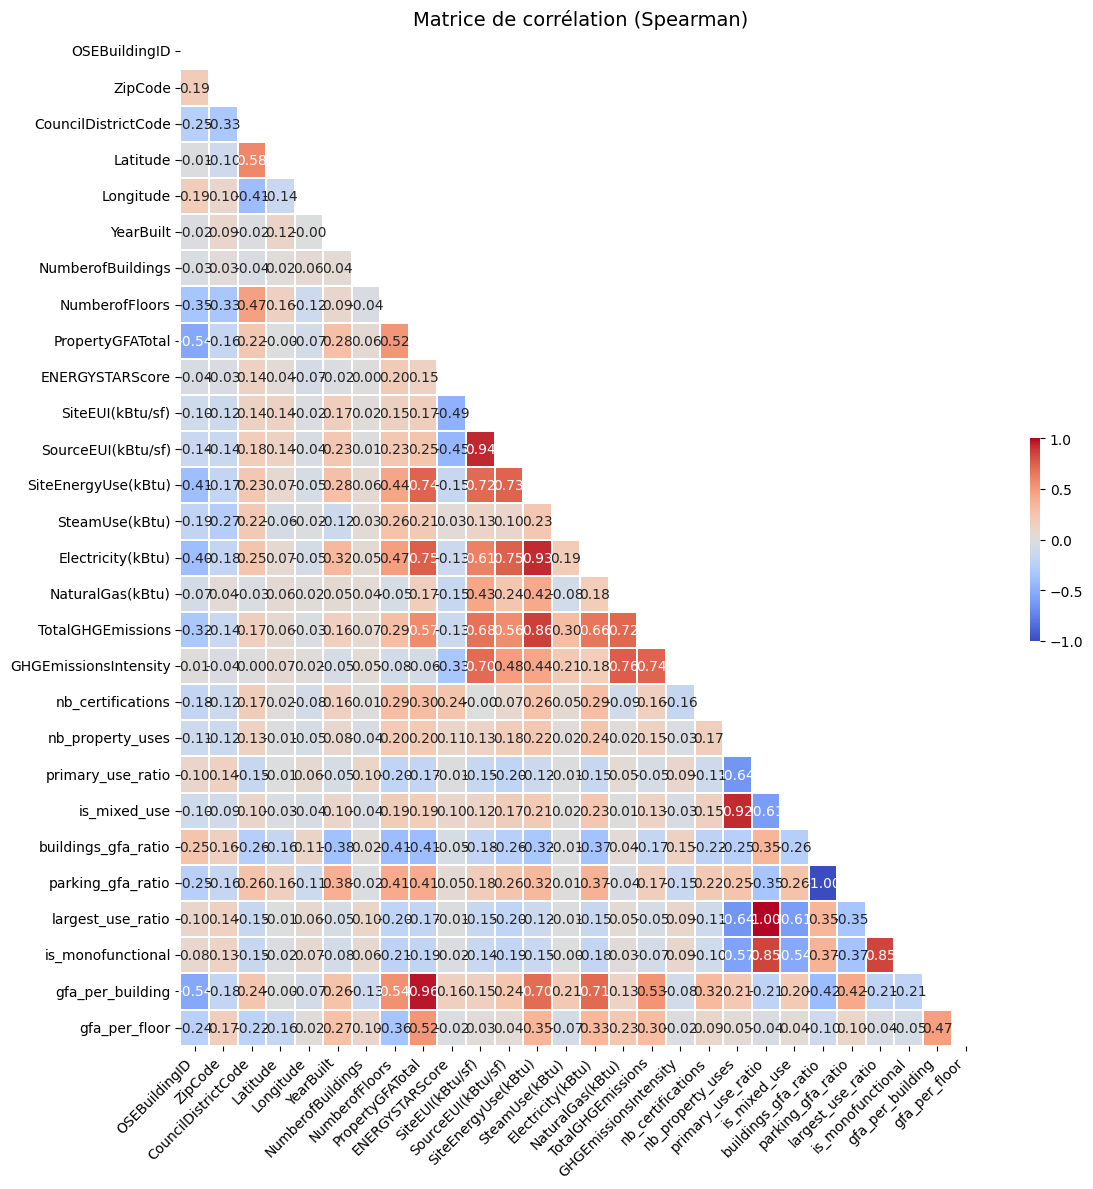

In [78]:

corr_matrix = df.select_dtypes(include="number").corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 12))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.2,
    cbar_kws={"shrink": 0.2}
)
plt.title("Matrice de corrélation (Spearman)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [79]:
corr = df.select_dtypes(include="number").corr(method="spearman")

mask = np.triu(np.ones_like(corr, dtype=bool)) # matrice de 1 de la même taille que corr + garde uniquement la partie triangulaire supérieure
corr_tri = corr.mask(mask) # suppression de la diagonale et de la partie supérieur de la matrice

strong_corr = (pd.DataFrame(
    corr_tri.unstack()
    .dropna()
    .loc[lambda x: abs(x) > 0.7]
    .sort_values(ascending=False)
    .reset_index()
    )
)
strong_corr.columns = ["level_0", "level_1", "corr"]
strong_corr

,level_0,level_1,corr
0,primary_use_ratio,largest_use_ratio,1.00
1,PropertyGFATotal,gfa_per_building,0.96
2,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),0.94
3,SiteEnergyUse(kBtu),Electricity(kBtu),0.93
4,nb_property_uses,is_mixed_use,0.92
5,SiteEnergyUse(kBtu),TotalGHGEmissions,0.86
6,primary_use_ratio,is_monofunctional,0.85
7,largest_use_ratio,is_monofunctional,0.85
8,NaturalGas(kBtu),GHGEmissionsIntensity,0.76
9,PropertyGFATotal,Electricity(kBtu),0.75


In [80]:
strong_corr_features = list(set(list(strong_corr['level_0'].values) + list(strong_corr['level_1'].values)))
X = df[strong_corr_features].replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(len(X.columns))]
vif_data[vif_data['VIF'] > 5]

/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,Electricity(kBtu),432.04
1,buildings_gfa_ratio,20.59
3,SiteEUI(kBtu/sf),38.45
4,SourceEUI(kBtu/sf),27.49
6,SiteEnergyUse(kBtu),993.77
7,TotalGHGEmissions,87.71
9,primary_use_ratio,inf
10,NaturalGas(kBtu),14.87
11,GHGEmissionsIntensity,6.67
12,largest_use_ratio,"9,007,199,254,740,992.00"


Des scores VIF supérieur à 5 indiquent généralement une forte multicolinéarité. Ces variables fortement corrélées risquent de biaiser nos modèles.
Les features suffixées EUI(kBtu/sf), sont des variables dont les valeurs sont ramenées à la surface par étage. Nous allons les supprimer car nous avons créer des variables pouvant permettre de ramener nos données à l'étage ou au building. Idem pour la variable GHGEmissionsIntensity

In [81]:
eui_features = search_componant(df, suffix='EUI(kBtu/sf)') + ['GHGEmissionsIntensity']
df.drop(eui_features, axis=1, inplace=True)

# Etape 2 - réaliser votre feature engineering

## Ajout de colonnes liée à l'âge du bâtiment

In [78]:
df.sample(5)

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,ListOfAllPropertyUseTypes,LargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,nb_certifications,first_cert_year,nb_property_uses,primary_use_ratio,is_mixed_use,buildings_gfa_ratio,parking_gfa_ratio,largest_use_ratio,is_monofunctional,gfa_per_building,gfa_per_floor
1431,21785,NonResidential,Other,AM Building,5907 4th Ave So,"98,108.00",2024049009,2,GREATER DUWAMISH,47.55,-122.33,1950,1.00,1,26660,Manufacturing/Industrial Plant,Manufacturing/Industrial Plant,NaN,"2,241,280.50",0.00,"2,241,280.00",0.00,15.62,0,NaN,1,1.00,0,1.00,0.00,1.00,1,"26,660.00","26,660.00"
2457,25709,NonResidential,Hotel,Weller & Second Associates,670 S. Weller Street,"98,104.00",5247802370,2,DOWNTOWN,47.60,-122.32,1908,1.00,3,28800,"Hotel, Restaurant",Hotel,NaN,"4,644,346.00",0.00,"1,218,294.00","3,426,052.00",190.45,0,NaN,2,0.75,1,1.00,0.00,0.75,0,"28,800.00","9,600.00"
2982,27704,NonResidential,K-12 School,Seattle Jewish Community School,12351 8th Ave NE,"98,125.00",6413600296,5,North,47.72,-122.32,1988,1.00,2,32961,K-12 School,K-12 School,86.00,"1,573,155.00",0.00,"446,659.00","1,126,496.00",62.94,0,NaN,1,1.00,0,1.00,0.00,1.00,1,"32,961.00","16,480.50"
895,20167,NonResidential,K-12 School,Ninth & Lenora Building,2030 9th Avenue,"98,121.00",0660001310,7,DOWNTOWN,47.62,-122.34,1957,1.00,2,21600,K-12 School,K-12 School,72.00,"1,261,536.75",0.00,"609,724.00","651,813.00",38.87,0,NaN,1,1.00,0,1.00,0.00,1.00,1,"21,600.00","10,800.00"
782,19855,NonResidential,Small- and Mid-Sized Office,Lowman & Hanford Building,616 First Avenue,"98,104.00",0939000125,7,DOWNTOWN,47.60,-122.33,1900,1.00,7,23622,"Office, Restaurant",Office,100.00,"552,007.50",0.00,"419,848.00","132,159.00",9.95,0,NaN,2,1.11,1,1.00,0.00,1.11,1,"23,622.00","3,374.57"


In [82]:
df["building_age"] = 2016 - df["YearBuilt"]

In [83]:
rep = ar.analyze_association(df, "SiteEnergyUse(kBtu)", "building_age")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : SiteEnergyUse(kBtu) × building_age
Test          : Corrélation de Spearman
Observations  : 1538/1538 (0 manquantes)

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
rho           : -0.277

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Effet faible



{'var_x': 'SiteEnergyUse(kBtu)',
 'var_y': 'building_age',
 'dtype_x': 'float64',
 'dtype_y': 'int64',
 'test': 'Corrélation de Spearman',
 'p_value': 0.0,
 'effect_size': -0.2771,
 'effect_size_name': 'rho',
 'n_total': 1538,
 'n_used': 1538,
 'n_missing': np.int64(0),
 'k_groups': None,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Effet faible'}

In [81]:
df["is_old_building"] = (df["building_age"] > 50).astype(int)

In [82]:
df.sample(2)

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,ListOfAllPropertyUseTypes,LargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,nb_certifications,first_cert_year,nb_property_uses,primary_use_ratio,is_mixed_use,buildings_gfa_ratio,parking_gfa_ratio,largest_use_ratio,is_monofunctional,gfa_per_building,gfa_per_floor,building_age,is_old_building
290,420,NonResidential,Other,Meridian (West),1506 6th Ave,"98,101.00",1976700045,7,DOWNTOWN,47.61,-122.33,1996,1.00,6,147852,"Office, Other - Restaurant/Bar, Parking, Retai...",Parking,NaN,"9,671,619.00",0.00,"7,122,619.00","2,548,999.00",185.03,0,NaN,4,0.44,1,0.42,0.58,0.44,0,"147,852.00","24,642.00",20,0
2222,24857,NonResidential,Retail Store,(ID24857) EMPIRE CENTER,6032 M L KING JR WAY S,"98,118.00",8113100170,2,SOUTHEAST,47.55,-122.28,1966,1.00,1,37883,"Retail Store, Supermarket/Grocery Store",Retail Store,88.00,"12,434,593.00",0.00,"5,359,975.00","7,074,617.00",413.10,0,NaN,2,0.76,1,1.00,0.00,0.76,0,"37,883.00","37,883.00",50,0


In [83]:
rep = ar.analyze_association(df, "SiteEnergyUse(kBtu)", "is_old_building")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : SiteEnergyUse(kBtu) × is_old_building
Test          : Kruskal-Wallis (is_old_building → SiteEnergyUse(kBtu))
Observations  : 1538/1538 (0 manquantes)
Groupes       : 2

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
eta²          : 0.060

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Effet moyen (0.06 ≤ η² < 0.14)



{'var_x': 'SiteEnergyUse(kBtu)',
 'var_y': 'is_old_building',
 'dtype_x': 'float64',
 'dtype_y': 'int64',
 'test': 'Kruskal-Wallis (is_old_building → SiteEnergyUse(kBtu))',
 'p_value': 0.0,
 'effect_size': 0.0605,
 'effect_size_name': 'eta²',
 'n_total': 1538,
 'n_used': 1538,
 'n_missing': np.int64(0),
 'k_groups': 2,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Effet moyen (0.06 ≤ η² < 0.14)'}

In [84]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "is_old_building")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : TotalGHGEmissions × is_old_building
Test          : Kruskal-Wallis (is_old_building → TotalGHGEmissions)
Observations  : 1538/1538 (0 manquantes)
Groupes       : 2

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
eta²          : 0.013

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Petit effet (0.01 ≤ η² < 0.06)



{'var_x': 'TotalGHGEmissions',
 'var_y': 'is_old_building',
 'dtype_x': 'float64',
 'dtype_y': 'int64',
 'test': 'Kruskal-Wallis (is_old_building → TotalGHGEmissions)',
 'p_value': 0.0,
 'effect_size': 0.0132,
 'effect_size_name': 'eta²',
 'n_total': 1538,
 'n_used': 1538,
 'n_missing': np.int64(0),
 'k_groups': 2,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Petit effet (0.01 ≤ η² < 0.06)'}

In [85]:
df["age_bin"] = pd.cut(
    df["building_age"],
    bins=[0,20,40,60,80,150],
    labels=["0-20","20-40","40-60","60-80","80+"]
)

In [86]:
rep = ar.analyze_association(df, "SiteEnergyUse(kBtu)", "age_bin") #TotalGHGEmissions
rep


📊  ANALYSE D'ASSOCIATION
Variables     : SiteEnergyUse(kBtu) × age_bin
Test          : Kruskal-Wallis (age_bin → SiteEnergyUse(kBtu))
Observations  : 1538/1538 (0 manquantes)
Groupes       : 5

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
eta²          : 0.086

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Effet moyen (0.06 ≤ η² < 0.14)



{'var_x': 'SiteEnergyUse(kBtu)',
 'var_y': 'age_bin',
 'dtype_x': 'float64',
 'dtype_y': 'category',
 'test': 'Kruskal-Wallis (age_bin → SiteEnergyUse(kBtu))',
 'p_value': 0.0,
 'effect_size': 0.0862,
 'effect_size_name': 'eta²',
 'n_total': 1538,
 'n_used': 1538,
 'n_missing': np.int64(0),
 'k_groups': 5,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Effet moyen (0.06 ≤ η² < 0.14)'}

In [87]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "age_bin") #TotalGHGEmissions
rep


📊  ANALYSE D'ASSOCIATION
Variables     : TotalGHGEmissions × age_bin
Test          : Kruskal-Wallis (age_bin → TotalGHGEmissions)
Observations  : 1538/1538 (0 manquantes)
Groupes       : 5

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
eta²          : 0.029

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Petit effet (0.01 ≤ η² < 0.06)



{'var_x': 'TotalGHGEmissions',
 'var_y': 'age_bin',
 'dtype_x': 'float64',
 'dtype_y': 'category',
 'test': 'Kruskal-Wallis (age_bin → TotalGHGEmissions)',
 'p_value': 0.0,
 'effect_size': 0.029,
 'effect_size_name': 'eta²',
 'n_total': 1538,
 'n_used': 1538,
 'n_missing': np.int64(0),
 'k_groups': 5,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Petit effet (0.01 ≤ η² < 0.06)'}

## Ajout d'une colonne surface log

In [88]:
df["log_gfa"] = np.log1p(df["PropertyGFATotal"])

In [89]:
rep = ar.analyze_association(df, "SiteEnergyUse(kBtu)", "log_gfa")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : SiteEnergyUse(kBtu) × log_gfa
Test          : Corrélation de Spearman
Observations  : 1538/1538 (0 manquantes)

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
rho           : 0.739

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Effet fort



{'var_x': 'SiteEnergyUse(kBtu)',
 'var_y': 'log_gfa',
 'dtype_x': 'float64',
 'dtype_y': 'float64',
 'test': 'Corrélation de Spearman',
 'p_value': 0.0,
 'effect_size': 0.739,
 'effect_size_name': 'rho',
 'n_total': 1538,
 'n_used': 1538,
 'n_missing': np.int64(0),
 'k_groups': None,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Effet fort'}

In [90]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "log_gfa")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : TotalGHGEmissions × log_gfa
Test          : Corrélation de Spearman
Observations  : 1538/1538 (0 manquantes)

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
rho           : 0.566

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Effet fort



{'var_x': 'TotalGHGEmissions',
 'var_y': 'log_gfa',
 'dtype_x': 'float64',
 'dtype_y': 'float64',
 'test': 'Corrélation de Spearman',
 'p_value': 0.0,
 'effect_size': 0.5663,
 'effect_size_name': 'rho',
 'n_total': 1538,
 'n_used': 1538,
 'n_missing': np.int64(0),
 'k_groups': None,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Effet fort'}

## Ajout colonnes de localisation (Neighborhood, CouncilDistrictCode...)

In [91]:
df["CouncilDistrictCode"] = df["CouncilDistrictCode"].astype("category")

In [92]:
df["Neighborhood"] = df["Neighborhood"].str.upper().str.strip()

## Ajout colonnes sources d’énergie (structurelles)

Très clairement, si j'ajoute la consommation d'énergie, ces variables risques de biaiser le modèle. Mais je peux faire des colonnes bool qui indique si un bâtiment utilise telle ou telle énergie.

In [93]:
df["has_gas"] = (df["NaturalGas(kBtu)"] > 0).astype(int)
df["has_electricity"] = (df["Electricity(kBtu)"] > 0).astype(int)
df["has_steam"] = (df["SteamUse(kBtu)"] > 0).astype(int) 

df.drop(["NaturalGas(kBtu)","Electricity(kBtu)","SteamUse(kBtu)","PropertyName", "Address", "TaxParcelIdentificationNumber","ZipCode","Latitude","Longitude"],axis=1,inplace=True)

In [94]:
df.isna().mean().sort_values(ascending=False)

first_cert_year             0.94
ENERGYSTARScore             0.36
largest_use_ratio           0.00
primary_use_ratio           0.00
Neighborhood                0.00
YearBuilt                   0.00
OSEBuildingID               0.00
BuildingType                0.00
NumberofFloors              0.00
NumberofBuildings           0.00
ListOfAllPropertyUseTypes   0.00
PropertyGFATotal            0.00
LargestPropertyUseType      0.00
SiteEnergyUse(kBtu)         0.00
PrimaryPropertyType         0.00
CouncilDistrictCode         0.00
nb_certifications           0.00
TotalGHGEmissions           0.00
is_mixed_use                0.00
nb_property_uses            0.00
buildings_gfa_ratio         0.00
parking_gfa_ratio           0.00
is_monofunctional           0.00
gfa_per_building            0.00
gfa_per_floor               0.00
building_age                0.00
is_old_building             0.00
age_bin                     0.00
log_gfa                     0.00
has_gas                     0.00
has_electr

# Etape 4 - Preprocessing

## Traitement des outliers

Plutôt que de supprimers les valeurs extrêmes, nous allons appliquer une transformation logarithmique afin de conserver un maximum d’observations tout en réduisant l’influence des outliers.

In [95]:
df["log_SiteEnergyUse"] = df["SiteEnergyUse(kBtu)"].apply(np.log1p)
df["log_TotalGHG"]  = df["TotalGHGEmissions"].apply(np.log1p)

## Séparation des colonnes catégoriques et nuémriques

In [96]:
df.head(1)

,OSEBuildingID,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,ListOfAllPropertyUseTypes,LargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions,nb_certifications,first_cert_year,nb_property_uses,primary_use_ratio,is_mixed_use,buildings_gfa_ratio,parking_gfa_ratio,largest_use_ratio,is_monofunctional,gfa_per_building,gfa_per_floor,building_age,is_old_building,age_bin,log_gfa,has_gas,has_electricity,has_steam,log_SiteEnergyUse,log_TotalGHG
0,1,NonResidential,Hotel,7,DOWNTOWN,1927,1.00,12,88434,Hotel,Hotel,60.00,"7,226,362.50",249.98,0,NaN,1,1.00,0,1.00,0.00,1.00,1,"88,434.00","7,369.50",89,1,80+,11.39,1,1,1,15.79,5.53


In [97]:
# J'enlève la certification pour le moment
numeric_features = [
    "YearBuilt", "building_age", "NumberofBuildings", "NumberofFloors", "PropertyGFATotal",
    #"ENERGYSTARScore","nb_certifications", "first_cert_year"
    "nb_property_uses", "primary_use_ratio", "is_mixed_use", 
    "buildings_gfa_ratio", "parking_gfa_ratio", "largest_use_ratio", "is_monofunctional", "log_gfa",
    "gfa_per_building", "gfa_per_floor",
    "is_old_building",
    "has_gas", "has_electricity", "has_steam"
]

In [98]:
categorical_features = [
    "PrimaryPropertyType",
    "Neighborhood",
    "CouncilDistrictCode",
    "age_bin",
    "LargestPropertyUseType",    
    "ListOfAllPropertyUseTypes"  
]

## Séparation en test train split

In [99]:
col_sel = numeric_features + categorical_features
X = df[col_sel]
y_energy = df["log_SiteEnergyUse"]

y_ghg = df["log_TotalGHG"]

In [100]:
X = X.copy()
X.columns = X.columns.astype(str)
numeric_features = [c for c in map(str, numeric_features) if c in X.columns]
categorical_features = [c for c in map (str, categorical_features) if c in X.columns]
X.info()

<class 'pandas.DataFrame'>
Index: 1538 entries, 0 to 3375
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   YearBuilt                  1538 non-null   int64   
 1   building_age               1538 non-null   int64   
 2   NumberofBuildings          1538 non-null   float64 
 3   NumberofFloors             1538 non-null   int64   
 4   PropertyGFATotal           1538 non-null   int64   
 5   nb_property_uses           1538 non-null   int64   
 6   primary_use_ratio          1534 non-null   float64 
 7   is_mixed_use               1538 non-null   int64   
 8   buildings_gfa_ratio        1538 non-null   float64 
 9   parking_gfa_ratio          1538 non-null   float64 
 10  largest_use_ratio          1534 non-null   float64 
 11  is_monofunctional          1538 non-null   int64   
 12  log_gfa                    1538 non-null   float64 
 13  gfa_per_building           1538 non-null   float6

In [101]:
X_train, X_test, y_train_energy, y_test_energy = train_test_split(
    X, y_energy, test_size=0.2, random_state=42
)

_, _, y_train_ghg, y_test_ghg = train_test_split(
    X, y_ghg, test_size=0.2, random_state=42
)

## Preprocessing

In [102]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), # Pas de valeurs manquantes dans le modèle (je le garde pour template)
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # Pas de valeurs manquantes dans le modèle (je le garde pour template)
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
], remainder="drop")

# Modèle de régression linéaire

## Energy model

In [103]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

In [104]:
from sklearn.linear_model import LinearRegression

energy_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

energy_model.fit(X_train, y_train_energy)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

## GHG model – Régression linéaire

In [105]:
ghg_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

ghg_model.fit(X_train, y_train_ghg)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

## Evaluation de Energy model

In [106]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred_energy = energy_model.predict(X_test)

print("Energy R2:", r2_score(y_test_energy, y_pred_energy))
print("Energy MAE:", mean_absolute_error(y_test_energy, y_pred_energy))

Energy R2: 0.7390303916755117
Energy MAE: 0.5156545901818527


In [107]:
y_pred_energy_real = np.exp(y_pred_energy)
y_test_energy_real = np.exp(y_test_energy)

print("Energy R2 (real):", r2_score(y_test_energy_real, y_pred_energy_real))
print("Energy MAE (real):", mean_absolute_error(y_test_energy_real, y_pred_energy_real))

Energy R2 (real): 0.33655424397768696
Energy MAE (real): 5024019.483662392


In [108]:
from sklearn.metrics import mean_squared_log_error

rmsle = np.sqrt(mean_squared_log_error(y_test_energy_real, y_pred_energy_real))
print("Energy RMSLE:", rmsle)

Energy RMSLE: 0.6780314302863086


Le modèle explique **74% de la variance en log-space**, ce qui montre que les caractéristiques structurelles des bâtiments (surface, âge, usage, etc.) sont fortement liées à la consommation énergétique.

En revanche, une fois reconverti en échelle réelle, la **performance chute (R² = 0.32)**, ce qui révèle :

- une forte asymétrie des données,

- une grande variabilité entre bâtiments.

- Le RMSLE de 0.68 signifie que le modèle se trompe en moyenne d’un facteur proche de 2.

## Evaluation de GHG model

In [109]:
y_pred_ghg = ghg_model.predict(X_test)

print("GHG R2:", r2_score(y_test_ghg, y_pred_ghg))
print("GHG MAE:", mean_absolute_error(y_test_ghg, y_pred_ghg))

GHG R2: 0.706383916069977
GHG MAE: 0.6252194518716091


In [110]:
y_pred_ghg_real = np.exp(y_pred_ghg)
y_test_ghg_real = np.exp(y_test_ghg)

print("GHG R2 (real):", r2_score(y_test_ghg_real, y_pred_ghg_real))
print("GHG MAE (real):", mean_absolute_error(y_test_ghg_real, y_pred_ghg_real))

GHG R2 (real): 0.31860017344274216
GHG MAE (real): 159.23607624527102


In [111]:
rmsle = np.sqrt(mean_squared_log_error(y_test_ghg_real, y_pred_ghg_real))
print("Energy RMSLE:", rmsle)

Energy RMSLE: 0.7685874087701969


Le modèle GHG explique correctement la structure générale des données en log-space (r2: 0.720).

Cependant, en échelle réelle, la performance chute fortement (R² = 0,10),

La variabilité est plus importante que pour l’énergie.

Cela suggère que les émissions de GES sont plus instables et probablement influencées par des variables non observées (mix énergétique réel, comportement des occupants, performance des équipements, etc.).

## Conclusion

Les modèles linéaires constituent une baseline solide :

Ils confirment que les caractéristiques structurelles des bâtiments expliquent une part importante de la performance énergétique.

Ils mettent également en évidence une forte hétérogénéité entre bâtiments.

Les erreurs restent importantes à l’échelle individuelle.

Ces résultats justifient le recours à des modèles non linéaires (Gradient Boosting, Random Forest, Dummy Mean...) afin d’améliorer la précision.

# Etape 5 - Comparaison des modèles

## Cross Validation sur les différents modèles

In [115]:
seed = 42
models_with_grids = [
    ("dummy_mean",
     DummyRegressor(strategy="mean"),
     {}),

    ("linear_regression",
     LinearRegression(),
     {}),

    ("elastic_net",
     ElasticNet(random_state=seed),
     {"model__alpha": [0.01, 0.1, 1.0],
      "model__l1_ratio": [0.2, 0.5, 0.8]}),

    ("svr",
     SVR(),
     {"model__C": [1, 10],
      "model__epsilon": [0.1, 0.2],
      "model__kernel": ["rbf"]}),

    ("random_forest",
     RandomForestRegressor(random_state=seed, n_jobs=-1),
     {"model__n_estimators": [200, 500],
      "model__max_depth": [None, 10, 20],
      "model__min_samples_split": [2, 5]}),

    ("lgbm",
     lgb.LGBMRegressor(random_state=seed),
     {"model__n_estimators": [200, 500],
      "model__learning_rate": [0.05, 0.1],
      "model__num_leaves": [31, 63]}),

    # ✅ XGBoost en régression (pas classifier)
    ("xgboost",
     XGBRegressor(
         random_state=seed,
         objective="reg:squarederror",
         n_jobs=-1
     ),
     {"model__n_estimators": [300, 600],
      "model__max_depth": [3, 6],
      "model__learning_rate": [0.05, 0.1]})
]

In [118]:
df_compare = tp.tune_and_compare_models(
    models_with_grids=models_with_grids,
    preprocessor=preprocessor,
    X_train=X_train, y_train=y_train_energy,
    X_test=X_test, y_test=y_test_energy,
    cv=5,
    seed=42
)

df_compare

AttributeError: module 'src.tunning_parameter' has no attribute 'tune_and_compare_models'

## Comparaison des modèles

In [112]:
baseline_energy = mdl.compare_resultat_pipeline(X_train, y_train_energy,preprocessor=preprocessor)
baseline_energy

Durée d'exécution de regression_pipeline: 5.483s
Durée d'exécution de regression_pipeline: 0.536s
Durée d'exécution de regression_pipeline: 0.489s
Durée d'exécution de regression_pipeline: 3.112s
Durée d'exécution de regression_pipeline: 22.901s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003962 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2069
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2069
[LightGBM] [Info] Number of data points in the train set: 1107, number of used features: 80
[LightGBM] [Info] Number of data points in the train set: 1107, number of used features: 79
[LightGBM] [Info] Auto-choosing col-wise multi-thr

/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with fea

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002800 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2070
[LightGBM] [Info] Number of data points in the train set: 1107, number of used features: 80
[LightGBM] [Info] Start training from score 14.971378
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2066
[LightGBM] [Info] Number of data points in the train set: 1107, number of used features: 80
[LightGBM] [Info] Start training from score 14.947683
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000667 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2063
[LightGBM] [Info] Number of data points in the train set: 1107, number of used features: 76
[LightGBM] [Info] Start training from score 14.978448


...

/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.243729 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2065
[LightGBM] [Info] Number of data points in the train set: 1107, number of used features: 78
[LightGBM] [Info] Start training from score 14.952763


/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with fea

Durée d'exécution de regression_pipeline: 5.375s
Durée d'exécution de compare_resultat_pipeline: 38.856s


modèle,fit_time_mean,score_time_mean,Test R2 (mean),Test R2 (std),Train R2 (mean),Test MAE (mean),Test MAE (std),Train MAE (mean),Test RMSE (mean),Train RMSE (mean)
svr,0.519981,0.067877,0.708194,0.039932,0.829960,0.512231,0.036377,0.355242,0.705906,0.539984
random_forest,7.848171,0.087612,0.719258,0.038771,0.961138,0.519336,0.032573,0.192713,0.689245,0.258121
linear_regression,0.139741,0.015982,0.704898,0.051728,0.864496,0.525415,0.034618,0.328664,0.705294,0.482012
lgbm,1.658241,0.026649,0.717053,0.027366,0.944982,0.530734,0.041993,0.230262,0.694343,0.307129
elastic_net,0.087569,0.018428,0.346462,0.036927,0.347854,0.839221,0.054541,0.839250,1.055934,1.057474
dummy_mean,0.053777,0.018239,-0.006995,0.005289,0.000000,1.049055,0.059537,1.048090,1.310437,1.309518


In [113]:
baseline_ghg = mdl.compare_resultat_pipeline(X_train, y_train_ghg,preprocessor=preprocessor)
baseline_ghg

Durée d'exécution de regression_pipeline: 0.487s
Durée d'exécution de regression_pipeline: 1.579s
Durée d'exécution de regression_pipeline: 0.305s
Durée d'exécution de regression_pipeline: 3.485s
Durée d'exécution de regression_pipeline: 17.802s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2074
[LightGBM] [Info] Number of data points in the train set: 1107, number of used features: 80
[LightGBM] [Info] Start training from score 4.039985
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000488 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2069
[LightGBM] [Info] Number of data points in the train set: 1107, number of used features: 

/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with fea

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2070
[LightGBM] [Info] Number of data points in the train set: 1107, number of used features: 80
[LightGBM] [Info] Start training from score 4.024713
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2066
[LightGBM] [Info] Number of data points in the train set: 1107, number of used features: 80
[LightGBM] [Info] Start training from score 4.008012


/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with fea

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000165 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2067
[LightGBM] [Info] Number of data points in the train set: 1107, number of used features: 78
[LightGBM] [Info] Start training from score 4.030065
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002917 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2063
[LightGBM] [Info] Number of data points in the train set: 1107, number of used features: 76
[LightGBM] [Info] Start training from score 4.037084


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2069
[LightGBM] [Info] Number of data points in the train set: 1107, number of used features: 78
[LightGBM] [Info] Start training from score 4.025090
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000596 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2065
[LightGBM] [Info] Number of data points in the train set: 1107, number of used features: 78
[LightGBM] [Info] Start training from score 4.014854


/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Durée d'exécution de regression_pipeline: 1.519s
Durée d'exécution de compare_resultat_pipeline: 25.182s


/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with fea

modèle,fit_time_mean,score_time_mean,Test R2 (mean),Test R2 (std),Train R2 (mean),Test MAE (mean),Test MAE (std),Train MAE (mean),Test RMSE (mean),Train RMSE (mean)
random_forest,6.147557,0.089649,0.683703,0.053002,0.957029,0.616986,0.035368,0.229738,0.811108,0.301914
svr,0.625668,0.073570,0.649423,0.081813,0.789245,0.619822,0.036524,0.442082,0.853562,0.668617
lgbm,0.483955,0.029085,0.659656,0.061438,0.934961,0.645751,0.044091,0.278768,0.841634,0.371429
linear_regression,0.121518,0.019536,0.627055,0.072289,0.834592,0.666202,0.051440,0.414520,0.883707,0.592360
elastic_net,0.050940,0.018214,0.224709,0.020130,0.230038,1.008015,0.067191,1.006813,1.279218,1.278066
dummy_mean,0.061412,0.024887,-0.007130,0.005180,0.000000,1.150549,0.070433,1.149949,1.457606,1.456607


### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE